In [1]:
import pathlib

from pathlib import Path
import platform
import os
import sys
import gc

import numpy as np
import matplotlib.pyplot as plt

if platform.system() == "Windows":
    pathlib.PosixPath = pathlib.WindowsPath

def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "MultiplePFAnalysis" / "__init__.py").is_file():
            return path
    raise FileNotFoundError("Could not find repository root containing MultiplePFAnalysis")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
    
import MultiplePFAnalysis

CACHE_DIR = Path(
    os.environ.get(
        "MPF_PREPROCESSED_CACHE",
        REPO_ROOT / "MultiplePFAnalysis" / "cache" / "preprocessed",
    )
).expanduser()
RAT_ID = "R2470"
from MultiplePFAnalysis.segmentation_helpers import (
    compute_raw_position_tuning,
)

STATS_MIN_OCCUPANCY_SECONDS = 1.0

def get_ratemap_min_max(ratemap):
    arr = np.asarray(ratemap, dtype=float)
    return np.nanmin(arr), np.nanmax(arr)
plt.close("all")
gc.collect()

cache_file = CACHE_DIR / f"{RAT_ID}_experiments.npy"

experiments = np.load(cache_file, allow_pickle=True).tolist()
print(f"Loaded {len(experiments)} experiments for {RAT_ID}")
print(f"Cache file: {cache_file}")

Loaded 5 experiments for R2470
Cache file: c:\Users\annap\Documents\GitHub\MultiplePFAnalysis\cache\preprocessed\R2470_experiments.npy


**Example for one Rat: Remapping Correlation Analysis, Stretching Part**

Non-Rotated Analysis for Environment A and B

c:\Users\annap\anaconda3\envs\mpf_analysis_new\lib\site-packages\numpy\lib\function_base.py:2559: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
c:\Users\annap\anaconda3\envs\mpf_analysis_new\lib\site-packages\numpy\lib\function_base.py:2560: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


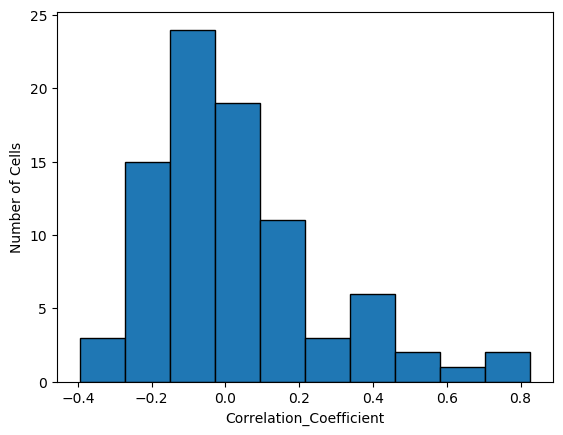

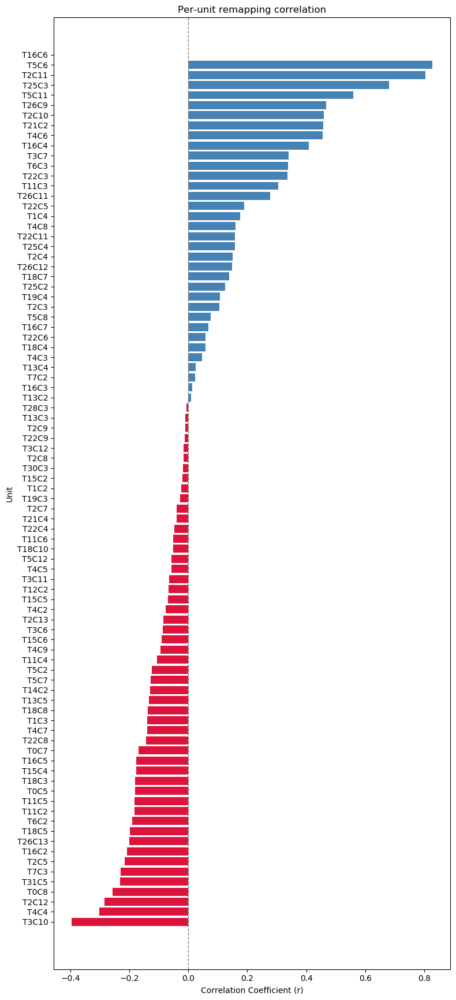

In [2]:
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
experiment_a = experiments[0]
experiment_b = experiments[1]


env_a_units = {}
env_b_units = {}

for unit in experiment_a.units:
    if unit.analysis.get("category") != "place_cell":
        continue

    unit_id_a = (unit.tetrode_nr, unit.cluster_id)
    spatial = unit.analysis["spatial_ratemaps"]
    ratemap_a = np.asarray(spatial["spike_rates_smoothed"], dtype=float)
    ratemap_a_flat = ratemap_a.flatten()
    zoom_factor = (125 / 125, 175 / 87.5)
    stretched = zoom(ratemap_a, zoom_factor, order=1)

    env_a_units[unit_id_a] = {
        "experiment": experiment_a,
        "unit": unit,
        "ratemap_a": ratemap_a,
        "stretched": stretched,
        "ratemap_a_flat": ratemap_a_flat,
    }

for unit in experiment_b.units:
    if unit.analysis.get("category") != "place_cell":
        continue

    unit_id_b = (unit.tetrode_nr, unit.cluster_id)
    spatial = unit.analysis["spatial_ratemaps"]
    ratemap_b = np.asarray(spatial["spike_rates_smoothed"], dtype=float)
    ratemap_b_flat = ratemap_b.flatten()

    env_b_units[unit_id_b] = {
        "experiment": experiment_b,
        "unit": unit,
        "ratemap_b": ratemap_b,
        "ratemap_b_flat": ratemap_b_flat,
    }


def per_unit_remapping_correlation(all_unit_ids, env_a_units, env_b_units, filter_out_cells_with_no_activity=False):
    results_units = {}
    results_histogramm = []


    for unit_id in all_unit_ids:
        if unit_id not in env_a_units or unit_id not in env_b_units:
            continue 

        units_a_stretched = env_a_units[unit_id]["stretched"].flatten()
        units_b_flat = env_b_units[unit_id]["ratemap_b_flat"]


        if not filter_out_cells_with_no_activity:
                    valid = np.isfinite(units_a_stretched) & np.isfinite(units_b_flat)
                    if np.sum(valid) > 3:
                        r = np.corrcoef(units_a_stretched[valid], units_b_flat[valid])[0, 1]
                    else:
                        continue
        else:
                    valid = np.isfinite(units_a_stretched) & np.isfinite(units_b_flat)
                    if np.sum(valid) > 3 and np.std(units_a_stretched) > 0 and np.std(units_b_flat) > 0:
                        r = np.corrcoef(units_a_stretched[valid], units_b_flat[valid])[0, 1]
                    else:
                        continue
        results_histogramm.append(r)
        results_units[unit_id] = r

    return results_units, results_histogramm


def Remapping_Histogramm (results_histogramm): 
    plt.hist(results_histogramm, bins=10, edgecolor='k')
    plt.xlabel('Correlation_Coefficient')
    plt.ylabel('Number of Cells');
    plt.show()


def Remapping_BarPlot (results_units): 
    sorted_items = sorted(
    results_units.items(),
    key=lambda x: np.inf if np.isnan(x[1]) else x[1]
    )
    unit_ids_sorted = [item[0] for item in sorted_items]
    r_values_sorted = [item[1] for item in sorted_items]
    labels = [f"T{uid[0]}C{uid[1]}" for uid in unit_ids_sorted]

    plt.figure(figsize=(8, max(4, len(labels) * 0.2)))
    plt.barh(
        labels,
        r_values_sorted,
        color=["crimson" if r < 0 else "steelblue" for r in r_values_sorted]
    )
    plt.xlabel("Correlation Coefficient (r)")
    plt.ylabel("Unit")
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    plt.title("Per-unit remapping correlation")
    plt.tight_layout()
    plt.show()




all_unit_ids = set(env_a_units.keys()) | set(env_b_units.keys())
results_units, results_histogramm = per_unit_remapping_correlation(all_unit_ids, env_a_units, env_b_units)
Remapping_Histogramm (results_histogramm)
Remapping_BarPlot(results_units)


Non-Rotated Analysis: Example Plot of the Ratemaps for Environment A and B

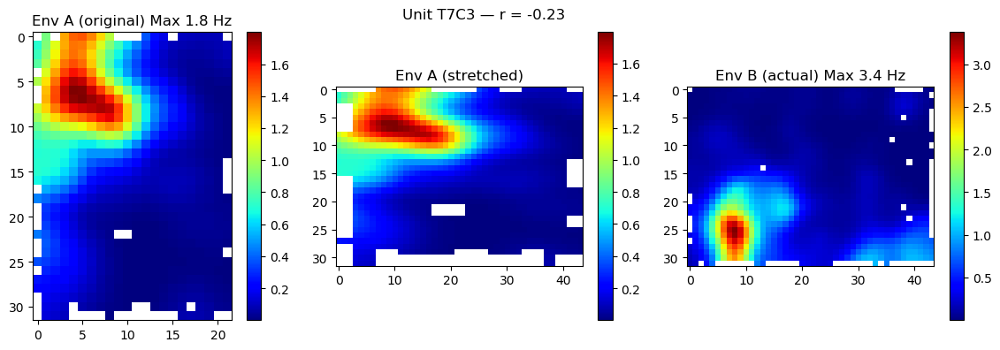

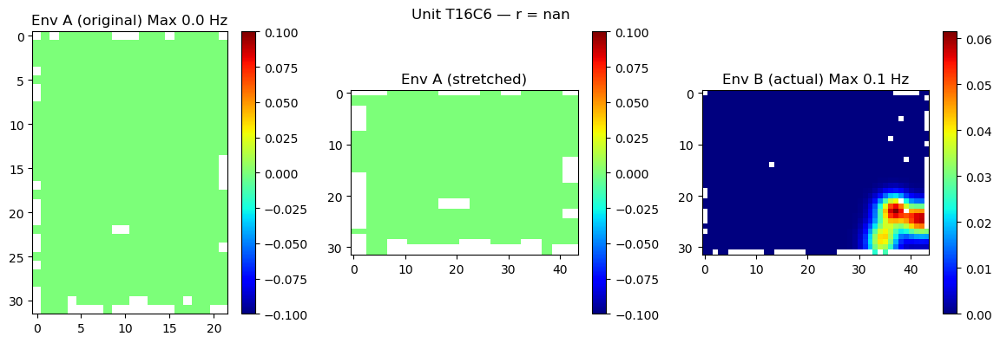

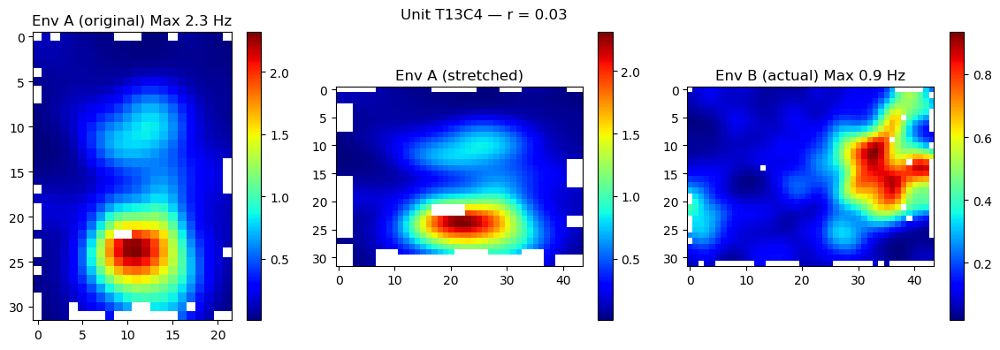

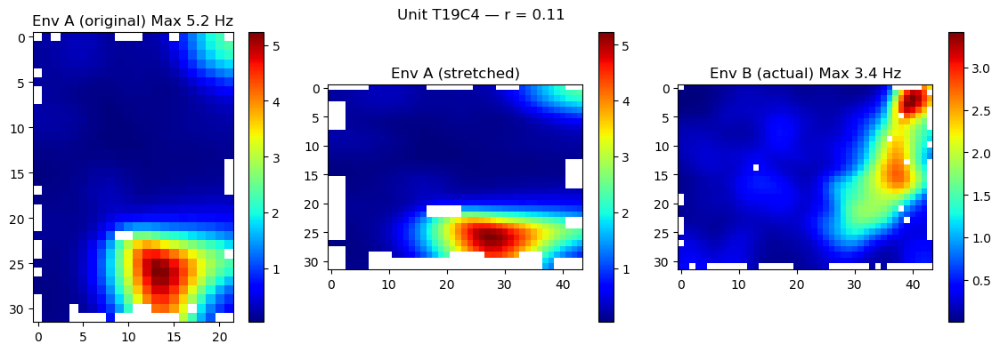

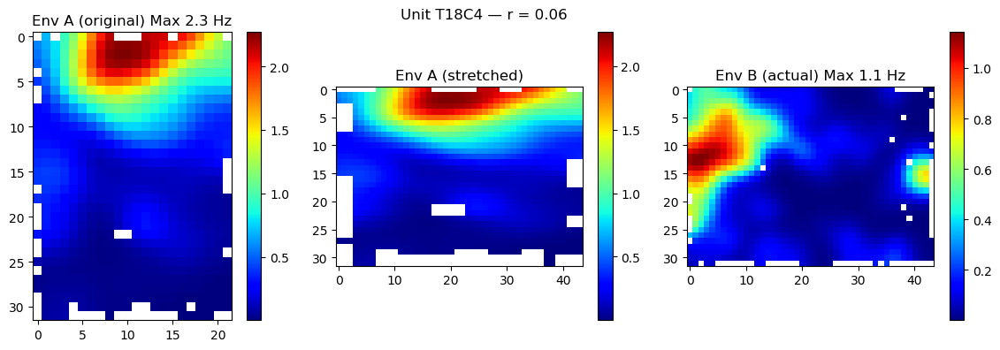

...

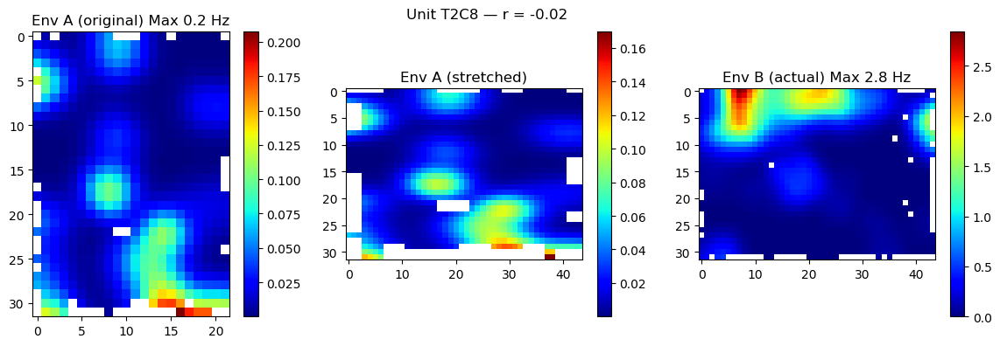

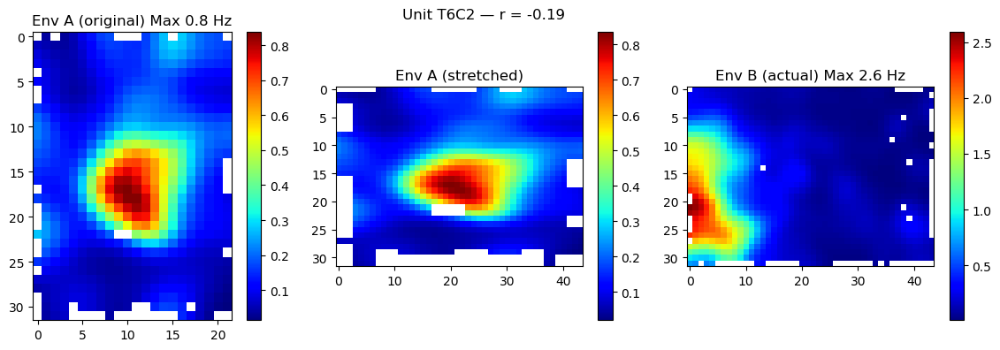

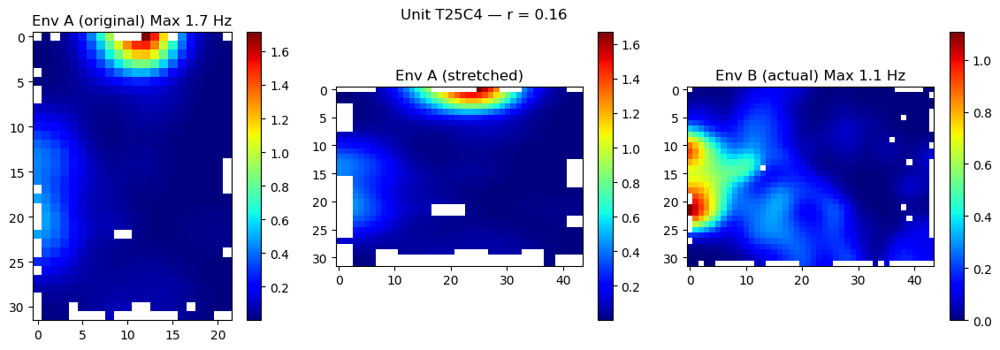

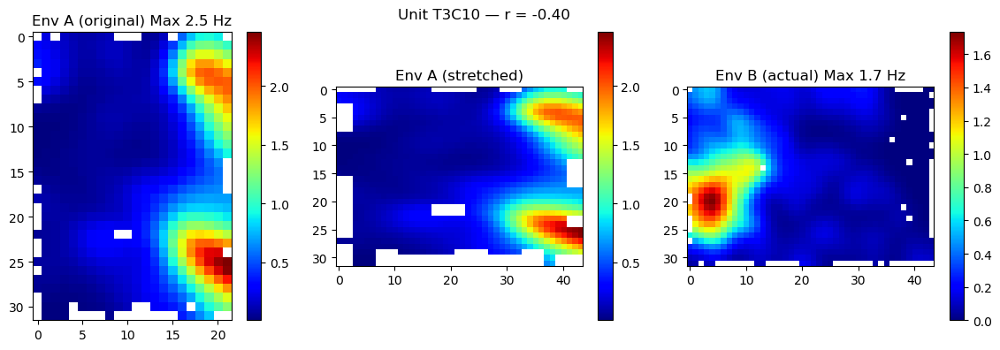

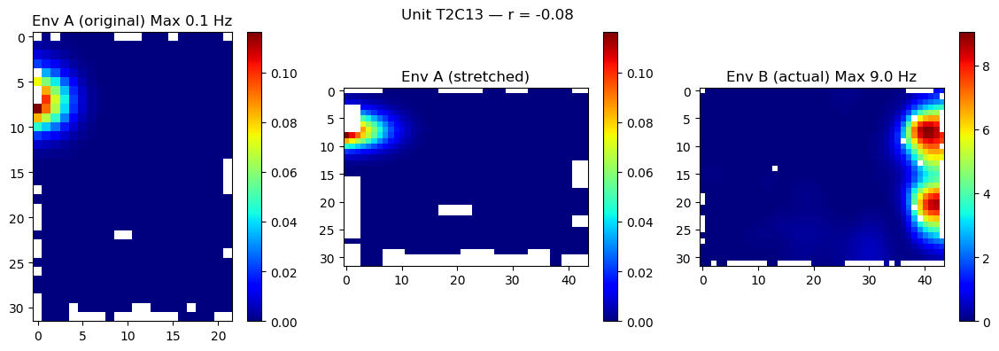

KeyboardInterrupt: 

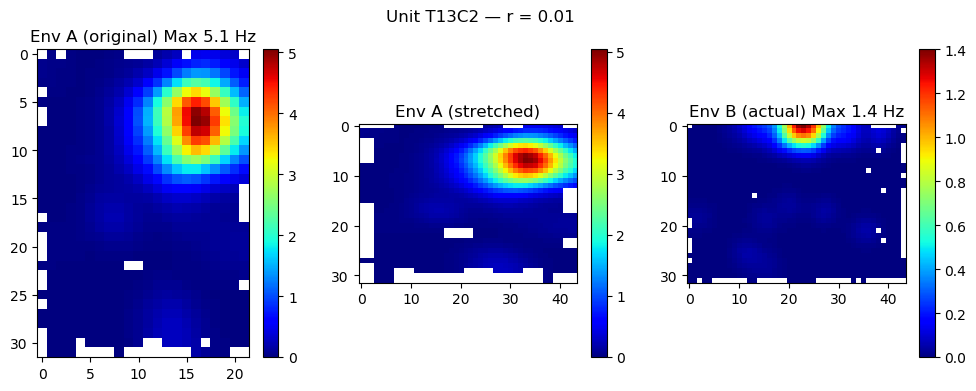

In [3]:
for unit_id in results_units:
    r = results_units[unit_id]

    ratemap_a = env_a_units[unit_id]["ratemap_a"]
    stretched = env_a_units[unit_id]["stretched"]
    ratemap_b = env_b_units[unit_id]["ratemap_b"]
    ratemap_min_a, ratemap_max_a = get_ratemap_min_max(ratemap_a)
    ratemap_min_b, ratemap_max_b = get_ratemap_min_max(ratemap_b)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Unit T{unit_id[0]}C{unit_id[1]} — r = {r:.2f}")

    im0 = axes[0].imshow(ratemap_a, cmap="jet")
    axes[0].set_title("Env A (original)" f" Max {ratemap_max_a:.1f} Hz" )
   
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(stretched, cmap="jet")
    axes[1].set_title("Env A (stretched)")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(ratemap_b, cmap="jet")
    axes[2].set_title("Env B (actual)"  f" Max {ratemap_max_b:.1f} Hz" )
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

Rotated Analysis: Example of Environment A and B for one rat


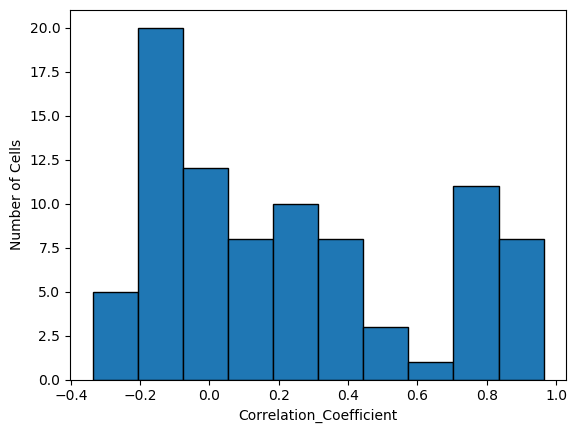

0.23022519223040996


In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from pathlib import Path
import statistics

def get_ratemap_min_max(ratemap):
    arr = np.asarray(ratemap)
    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)

    return min_val, max_val

experiment_a = experiments[0]
experiment_b = experiments[1]

env_a_units = {}
env_b_units = {}

for unit in experiment_b.units:
    if unit.analysis.get("category") != "place_cell":
        continue

    unit_id_b = (unit.tetrode_nr, unit.cluster_id)
    spatial = unit.analysis["spatial_ratemaps"]
    ratemap_b = np.asarray(spatial["spike_rates_smoothed"], dtype=float)
    ratemap_b_flat = ratemap_b.flatten()

    env_b_units[unit_id_b] = {
        "experiment": experiment_b,
        "unit": unit,
        "ratemap_b": ratemap_b,
        "ratemap_b_flat": ratemap_b_flat,
    }
first_unit_data = next(iter(env_b_units.values()))
target_shape = first_unit_data["ratemap_b"].shape

for unit in experiment_a.units:
    if unit.analysis.get("category") != "place_cell":
        continue

    unit_id_a = (unit.tetrode_nr, unit.cluster_id)
    spatial = unit.analysis["spatial_ratemaps"]
    ratemap_a = np.asarray(spatial["spike_rates_smoothed"], dtype=float)
    ratemap_a_rotated = np.flipud(ratemap_a.T)

    zoom_factor = (
        target_shape[0] / ratemap_a_rotated.shape[0],
        target_shape[1] / ratemap_a_rotated.shape[1],  
    )

    stretched_rotated_ratemap_a = zoom(ratemap_a_rotated, zoom_factor, order=1)

    ratemap_a_stretched_rotated_flat = stretched_rotated_ratemap_a.flatten()
                    
    env_a_units[unit_id_a] = {
        "experiment": experiment_a,
        "unit": unit,
        "ratemap_a": ratemap_a,
        "ratemap_a_rotated": ratemap_a_rotated,
        "stretched_rotated_ratemap_a": stretched_rotated_ratemap_a,
        "ratemap_a_stretched_rotated_flat": ratemap_a_stretched_rotated_flat,
    }



def per_unit_remapping_correlation_rotated(all_unit_ids, env_a_units, env_b_units, filter_out_cells_with_no_activity=True):
    results_units_rotated = {}
    results_histogramm_rotated = []


    for unit_id in all_unit_ids:
        if unit_id not in env_a_units or unit_id not in env_b_units:
            continue 

        ratemap_a_stretched_rotated_flat = env_a_units[unit_id]["ratemap_a_stretched_rotated_flat"].flatten()
        ratemap_a_stretched_rotated = env_a_units[unit_id]["stretched_rotated_ratemap_a"].flatten()
        ratemap_b_flat = env_b_units[unit_id]["ratemap_b_flat"]


        if not filter_out_cells_with_no_activity:
                    valid = np.isfinite(ratemap_a_stretched_rotated_flat) & np.isfinite(ratemap_b_flat)
                    if np.sum(valid) > 3:
                        r = np.corrcoef(ratemap_a_stretched_rotated_flat[valid], ratemap_b_flat[valid])[0, 1]
                    else:
                        r = 0
        else:
                    valid = np.isfinite(ratemap_a_stretched_rotated_flat) & np.isfinite(ratemap_b_flat)
                    min_val_a, max_val_a = get_ratemap_min_max(ratemap_a_stretched_rotated_flat) 
                    min_val_b, max_val_b = get_ratemap_min_max(ratemap_b_flat) 
                    if np.sum(valid) > 3 and max_val_a > 0 and max_val_b > 0:
                        r = np.corrcoef(ratemap_a_stretched_rotated_flat[valid], ratemap_b_flat[valid])[0, 1]
                    else:
                        continue
        results_histogramm_rotated.append(r)
        results_units_rotated[unit_id] = r

    return results_units_rotated, results_histogramm_rotated



def Remapping_Histogramm (results_histogramm_rotated): 
    plt.hist(results_histogramm_rotated, bins=10, edgecolor='k')
    plt.xlabel('Correlation_Coefficient')
    plt.ylabel('Number of Cells');
    plt.show()


def Remapping_BarPlot (results_units): 
    sorted_items = sorted(
    results_units.items(),
    key=lambda x: np.inf if np.isnan(x[1]) else x[1]
    )
    unit_ids_sorted = [item[0] for item in sorted_items]
    r_values_sorted = [item[1] for item in sorted_items]
    labels = [f"T{uid[0]}C{uid[1]}" for uid in unit_ids_sorted]

    plt.figure(figsize=(8, max(4, len(labels) * 0.2)))
    plt.barh(
        labels,
        r_values_sorted,
        color=["crimson" if r < 0 else "steelblue" for r in r_values_sorted]
    )
    plt.xlabel("Correlation Coefficient (r)")
    plt.ylabel("Unit")
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    plt.title("Per-unit remapping correlation")
    plt.tight_layout()
    plt.show()


all_unit_ids = set(env_a_units.keys()) | set(env_b_units.keys())
results_units_rotated= {}
results_histogramm_rotated = []
results_units_rotated, results_histogramm_rotated = per_unit_remapping_correlation_rotated(all_unit_ids, env_a_units, env_b_units)
Remapping_Histogramm (results_histogramm_rotated)



mean_correlation = statistics.mean(results_histogramm_rotated)
print(mean_correlation)


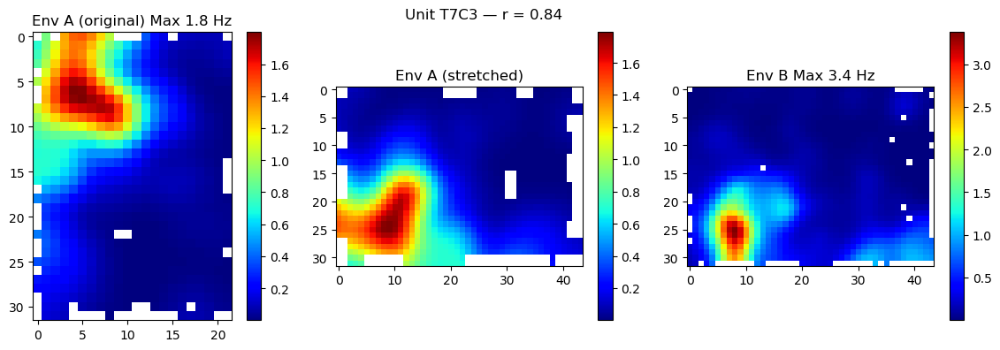

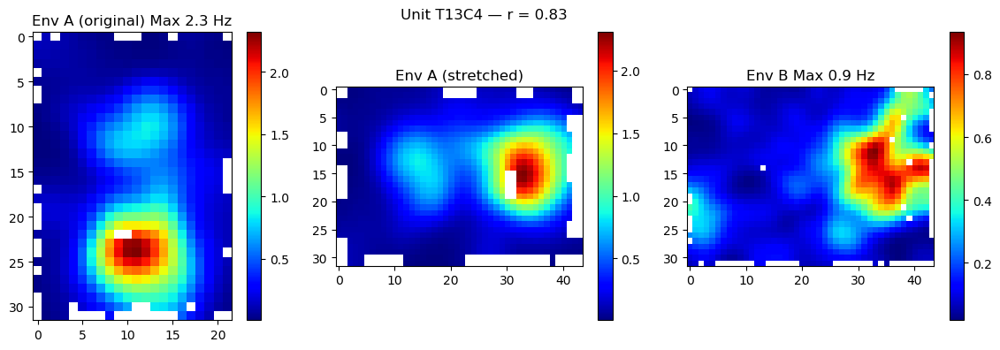

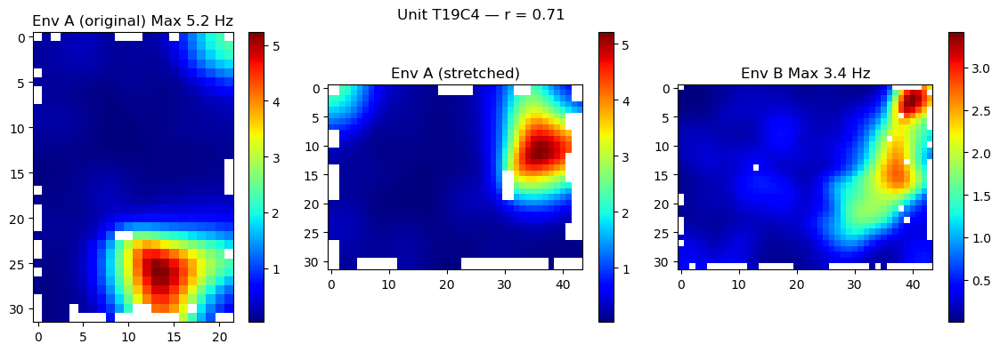

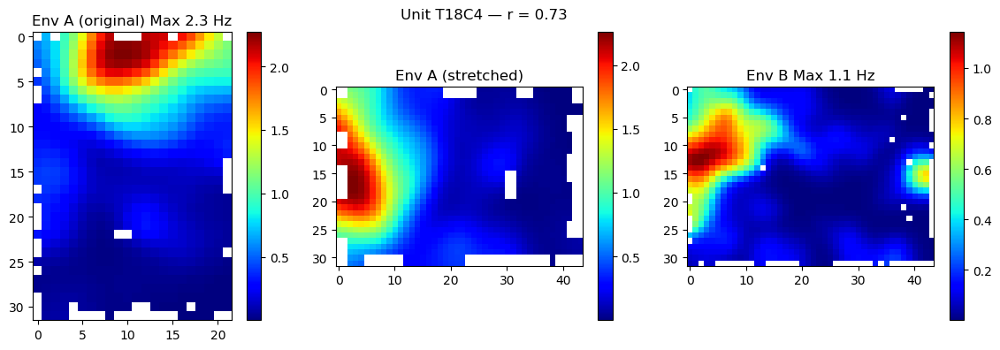

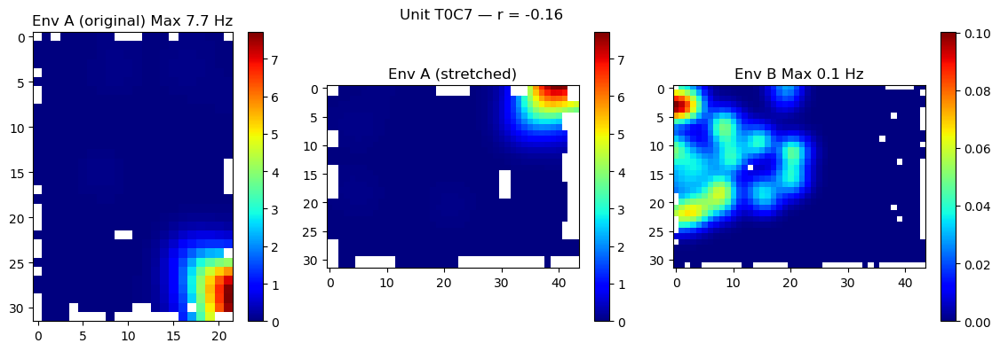

...

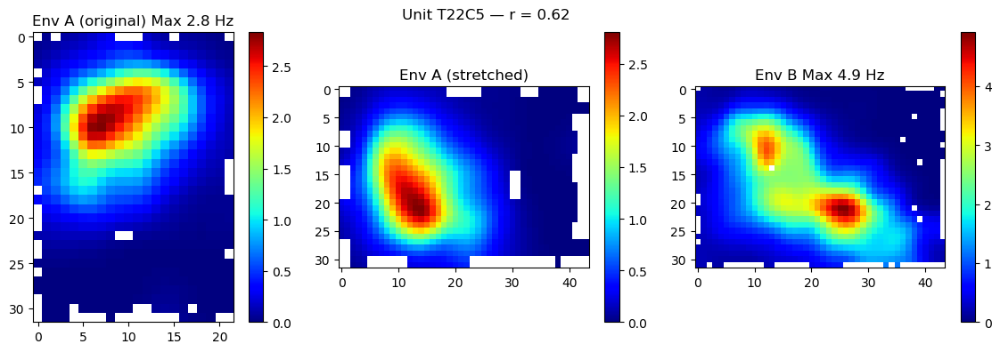

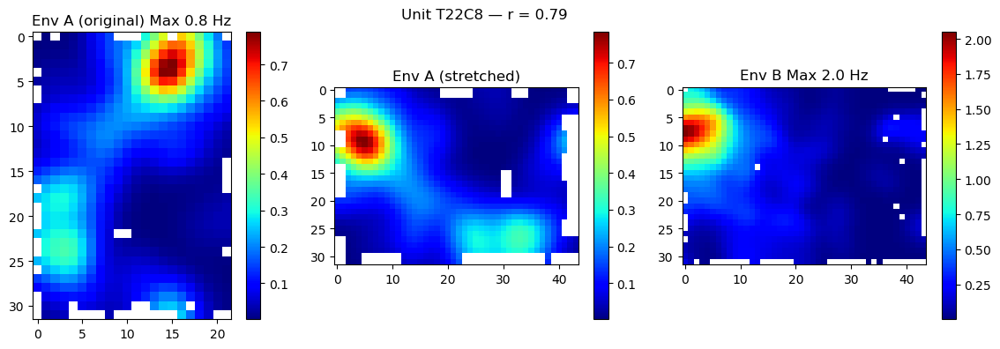

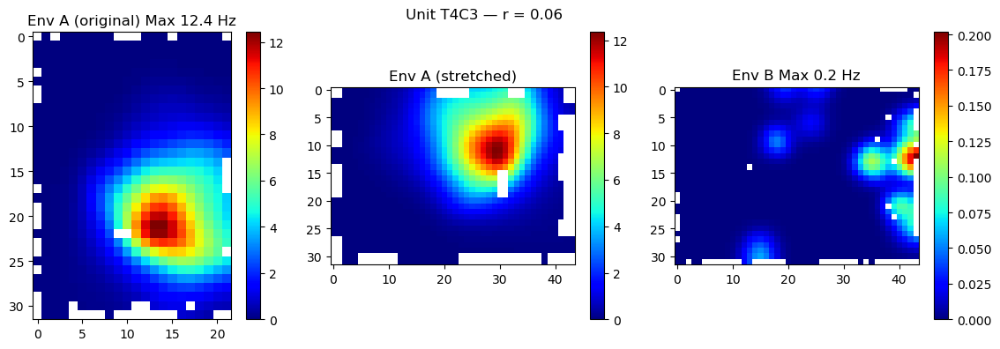

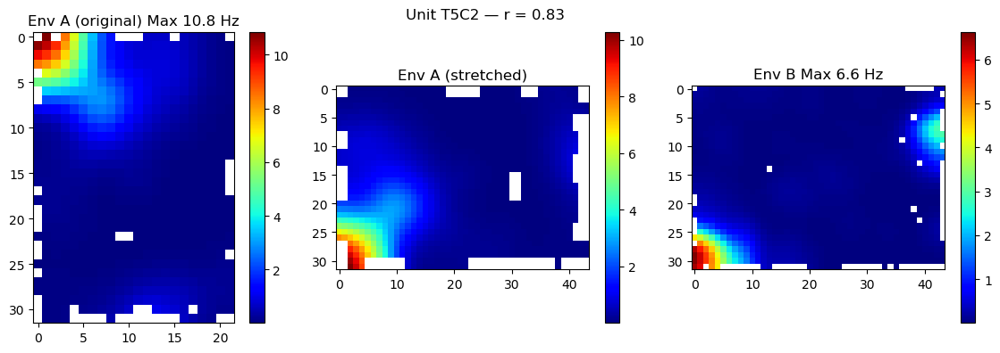

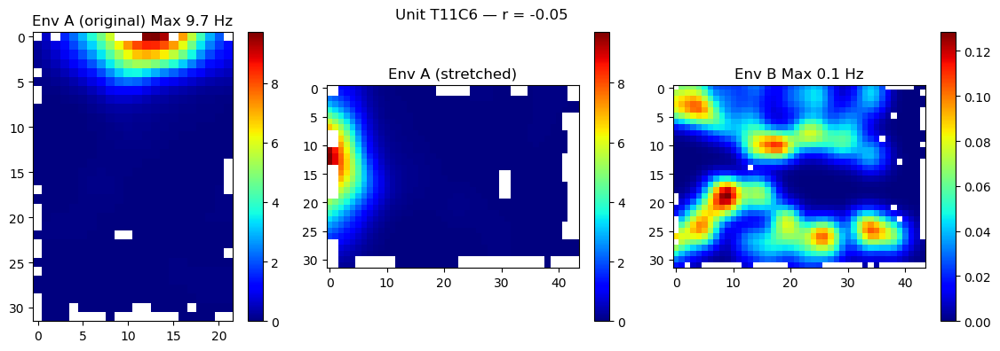

In [ ]:
for unit_id in results_units_rotated:
    r = results_units_rotated[unit_id]

    ratemap_a = env_a_units[unit_id]["ratemap_a"]
    stretched = env_a_units[unit_id]["stretched_rotated_ratemap_a"]
    ratemap_b = env_b_units[unit_id]["ratemap_b"]
    ratemap_min_a, ratemap_max_a = get_ratemap_min_max(ratemap_a)
    ratemap_min_b, ratemap_max_b = get_ratemap_min_max(ratemap_b)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Unit T{unit_id[0]}C{unit_id[1]} — r = {r:.2f}")

    im0 = axes[0].imshow(ratemap_a, cmap="jet")
    axes[0].set_title("Env A (original)" f" Max {ratemap_max_a:.1f} Hz" )
   
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(stretched, cmap="jet")
    axes[1].set_title("Env A (stretched)")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(ratemap_b, cmap="jet")
    axes[2].set_title("Env B"  f" Max {ratemap_max_b:.1f} Hz" )
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()


Example of rotating cells for one rat between Environment A and Environment B: Scatterplot

86 common units, 86 after dropping NaNs


(-1, 1)

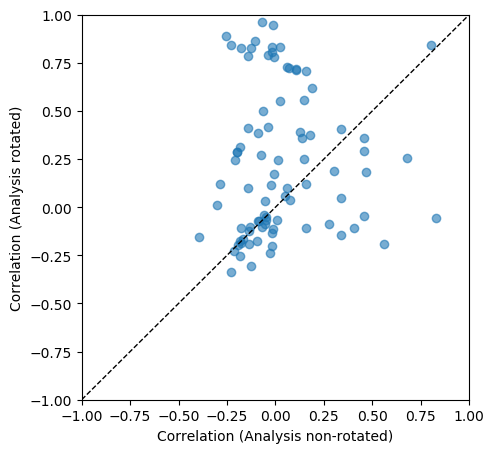

In [ ]:
from scipy import stats


common_ids = sorted(set(results_units.keys()) & set(results_units_rotated.keys()))

filtered_ids = []
for uid in common_ids:
    if not np.isnan(results_units[uid]) and not np.isnan(results_units_rotated[uid]):
        filtered_ids.append(uid)

print(f"{len(common_ids)} common units, {len(filtered_ids)} after dropping NaNs")

corr_A = np.array([results_units[uid] for uid in common_ids])
corr_B_rotated = np.array([results_units_rotated[uid] for uid in common_ids])

plt.figure(figsize=(5,5))
plt.scatter(corr_A, corr_B_rotated, alpha=0.6)
plt.plot([-1,1],[-1,1],'k--', lw=1) 
plt.xlabel('Correlation (Analysis non-rotated)')
plt.ylabel('Correlation (Analysis rotated)')
plt.xlim(-1,1); plt.ylim(-1,1)

Control all Rotations of Environment A and B

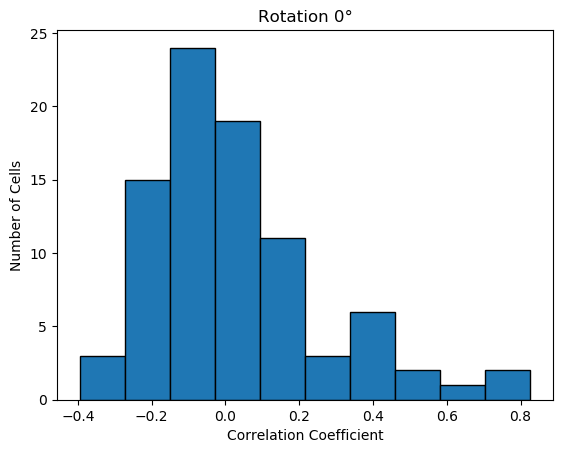

mean correlation: 0.028316602747960388
median correlation: -0.026131033325586462


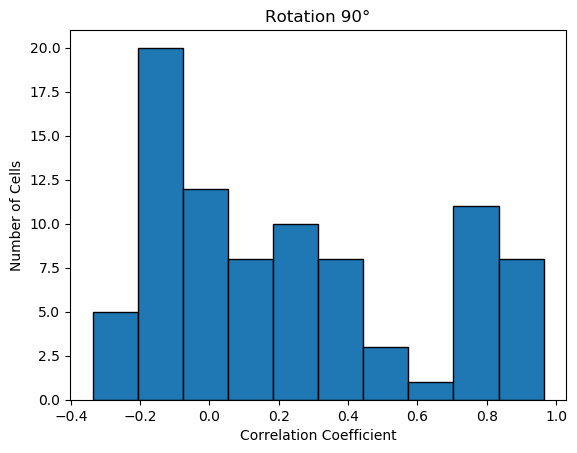

mean correlation: 0.23022519223040996
median correlation: 0.14477454043823645


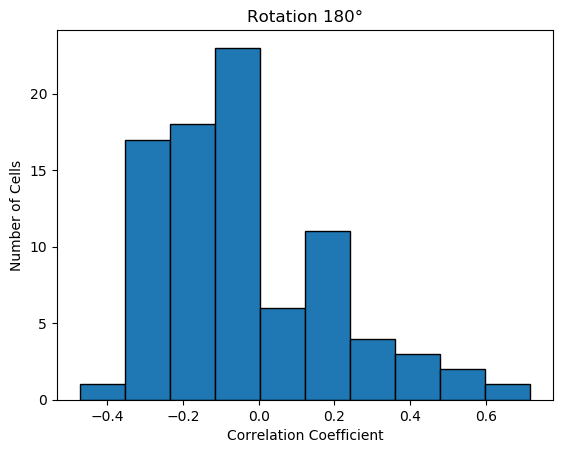

mean correlation: -0.036395658567750955
median correlation: -0.0859214344457227


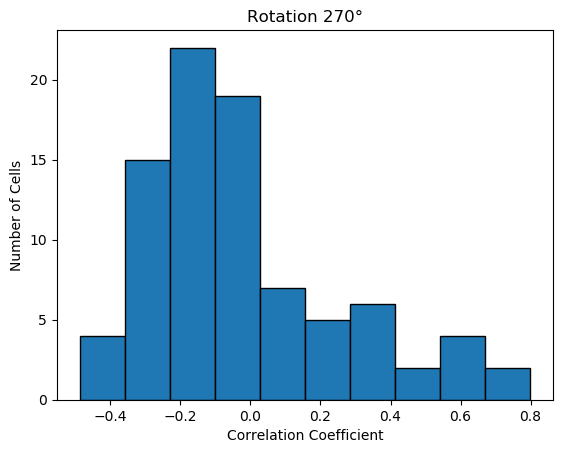

mean correlation: -0.02477727778287173
median correlation: -0.08779241580539965


In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import statistics

import numpy as np
from scipy import stats

def get_ratemap_min_max(ratemap):
    arr = np.asarray(ratemap)
    return np.nanmin(arr), np.nanmax(arr)

experiment_a = experiments[0]
experiment_b = experiments[1]

env_a_units = {}
env_b_units = {}


for unit in experiment_b.units:
    if unit.analysis.get("category") != "place_cell":
        continue

    unit_id_b = (unit.tetrode_nr, unit.cluster_id)
    spatial = unit.analysis["spatial_ratemaps"]
    ratemap_b = np.asarray(spatial["spike_rates_smoothed"], dtype=float)

    env_b_units[unit_id_b] = {
        "experiment": experiment_b,
        "unit": unit,
        "ratemap_b": ratemap_b,
        "ratemap_b_flat": ratemap_b.flatten(),
    }

target_shape = next(iter(env_b_units.values()))["ratemap_b"].shape

for unit in experiment_a.units:
    if unit.analysis.get("category") != "place_cell":
        continue

    unit_id_a = (unit.tetrode_nr, unit.cluster_id)
    spatial = unit.analysis["spatial_ratemaps"]
    ratemap_a = np.asarray(spatial["spike_rates_smoothed"], dtype=float)

    rotated_0 = ratemap_a
    rotated_90  = np.flipud(ratemap_a.T)
    rotated_180 = np.flipud(rotated_90.T)
    rotated_270 = np.flipud(rotated_180.T)

    def stretch(rotated):
        zf = (
            target_shape[0] / rotated.shape[0],
            target_shape[1] / rotated.shape[1],
        )
        return zoom(rotated, zf, order=1)
    
    stretched_0  = stretch(rotated_0)
    stretched_90  = stretch(rotated_90)
    stretched_180 = stretch(rotated_180)
    stretched_270 = stretch(rotated_270)

    env_a_units[unit_id_a] = {
        "experiment": experiment_a,
        "unit": unit,
        "ratemap_a": ratemap_a,
        "rotated_0":  rotated_0,
        "rotated_90":  rotated_90,
        "rotated_180": rotated_180,
        "rotated_270": rotated_270,
        "stretched_0":  stretched_0,
        "stretched_90":  stretched_90,
        "stretched_180": stretched_180,
        "stretched_270": stretched_270,
        "flat_0":  stretched_0.flatten(),
        "flat_90":  stretched_90.flatten(),
        "flat_180": stretched_180.flatten(),
        "flat_270": stretched_270.flatten(),
    }


def per_unit_remapping_correlation_different_rotations(all_unit_ids, env_a_units, env_b_units,rotation=90,filter_out_cells_with_no_activity=True):

    flat_key = f"flat_{rotation}"

    results_units = {}
    results_histogram = []

    for unit_id in all_unit_ids:
        if unit_id not in env_a_units or unit_id not in env_b_units:
            continue

        ratemap_a_flat = env_a_units[unit_id][flat_key]
        ratemap_b_flat = env_b_units[unit_id]["ratemap_b_flat"]

        valid = np.isfinite(ratemap_a_flat) & np.isfinite(ratemap_b_flat)

        if filter_out_cells_with_no_activity:
            _, max_val_a = get_ratemap_min_max(ratemap_a_flat)
            _, max_val_b = get_ratemap_min_max(ratemap_b_flat)
            passes = np.sum(valid) > 3 and max_val_a > 0 and max_val_b > 0
        else:
            passes = np.sum(valid) > 3

        if not passes:
            continue

        r = np.corrcoef(ratemap_a_flat[valid], ratemap_b_flat[valid])[0, 1]
        results_histogram.append(r)
        results_units[unit_id] = r

    return results_units, results_histogram


def Remapping_Histogramm(results_histogram, title=""):
    plt.hist(results_histogram, bins=10, edgecolor='k')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Number of Cells')
    plt.title(title)
    plt.show()

all_unit_ids = set(env_a_units.keys()) | set(env_b_units.keys())
results_units_0,   results_hist_0   = per_unit_remapping_correlation_different_rotations(all_unit_ids, env_a_units, env_b_units, rotation=0)
results_units_90,  results_hist_90  = per_unit_remapping_correlation_different_rotations(all_unit_ids, env_a_units, env_b_units, rotation=90)
results_units_180, results_hist_180 = per_unit_remapping_correlation_different_rotations(all_unit_ids, env_a_units, env_b_units, rotation=180)
results_units_270, results_hist_270 = per_unit_remapping_correlation_different_rotations(all_unit_ids, env_a_units, env_b_units, rotation=270)

Remapping_Histogramm(results_hist_0,  title="Rotation 0°")
median_correlation_0 = statistics.median(results_hist_0)
mean_correlation_0 = statistics.mean(results_hist_0)
print(f"mean correlation: {mean_correlation_0}")
print(f"median correlation: {median_correlation_0}")

Remapping_Histogramm(results_hist_90,  title="Rotation 90°")
median_correlation_90 = statistics.median(results_hist_90)
mean_correlation_90 = statistics.mean(results_hist_90)
print(f"mean correlation: {mean_correlation_90}")
print(f"median correlation: {median_correlation_90}")

Remapping_Histogramm(results_hist_180, title="Rotation 180°")
mean_correlation_180 = statistics.mean(results_hist_180)
median_correlation_180 = statistics.median(results_hist_180)
print(f"mean correlation: {mean_correlation_180}")
print(f"median correlation: {median_correlation_180}")

Remapping_Histogramm(results_hist_270, title="Rotation 270°")
median_correlation_270 = statistics.median(results_hist_270)
mean_correlation_270 = statistics.mean(results_hist_270)
print(f"mean correlation: {mean_correlation_270}")
print(f"median correlation: {median_correlation_270}")
 

Rotation Remapping Analysis for Environemnt A and B with Ratemaps

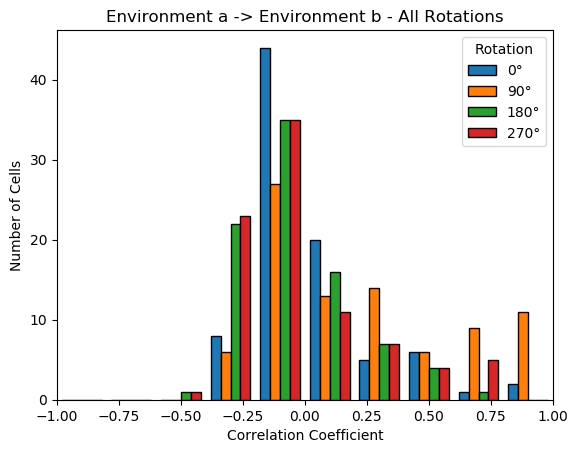

[Environment a -> Environment b] n units for statistical test: 86
[Environment a -> Environment b] n units before dropping NaNs: 86
[Environment a -> Environment b] Medians
  0°   : -0.026
  90°  : 0.145
 180°  : -0.086
 270°  : -0.088
[Environment a -> Environment b] Means
  0°   : 0.028
  90°  : 0.230
 180°  : -0.036
 270°  : -0.025


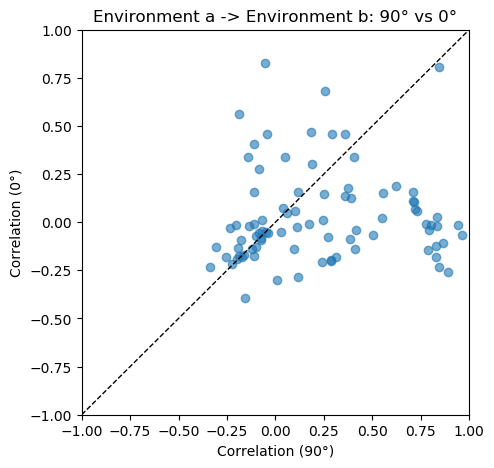

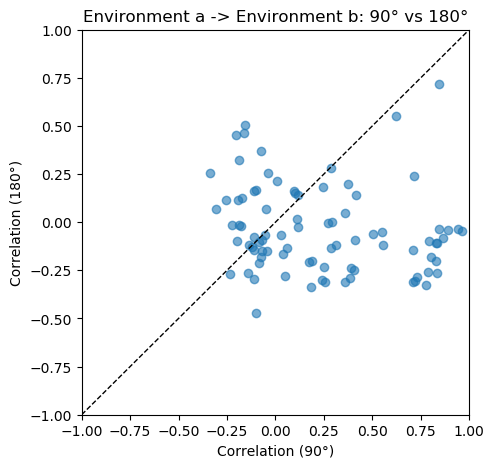

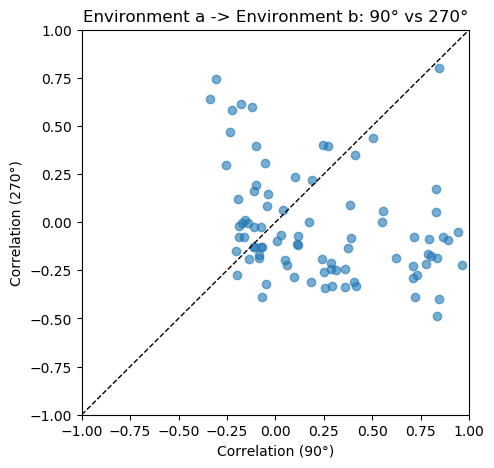

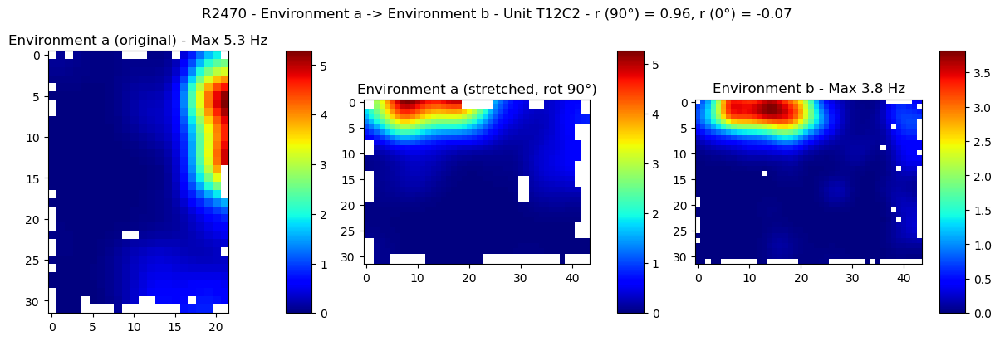

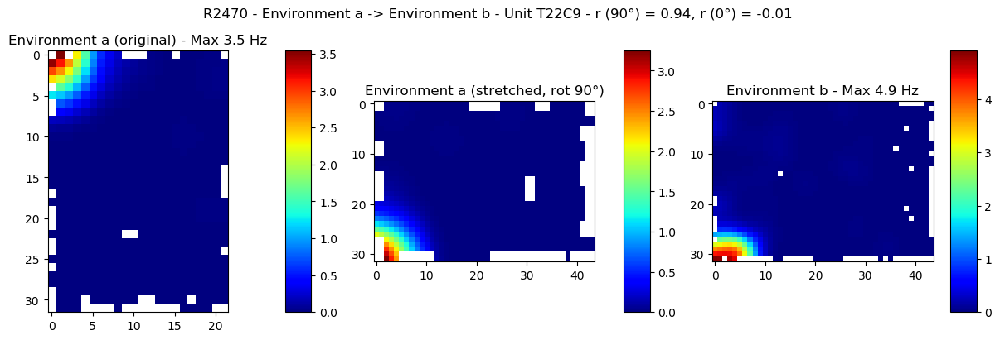

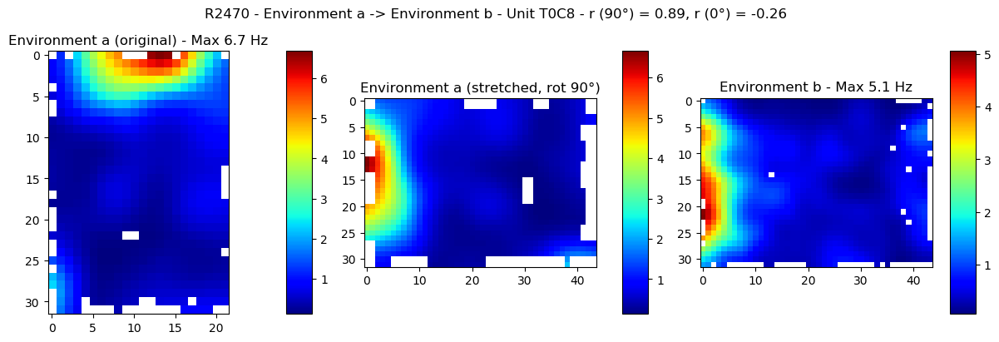

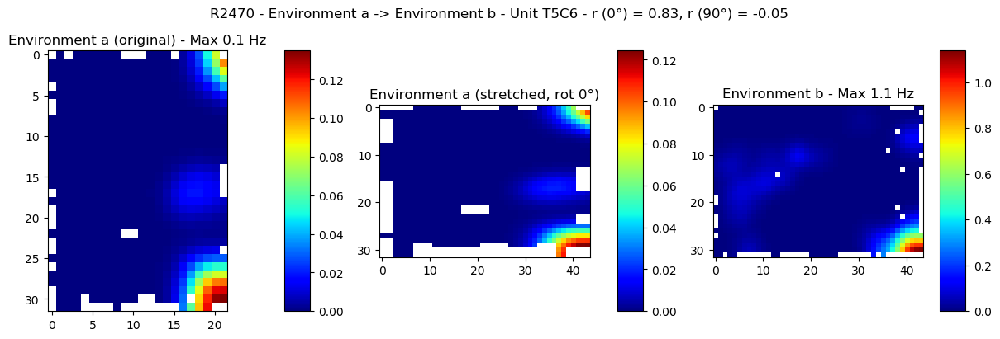

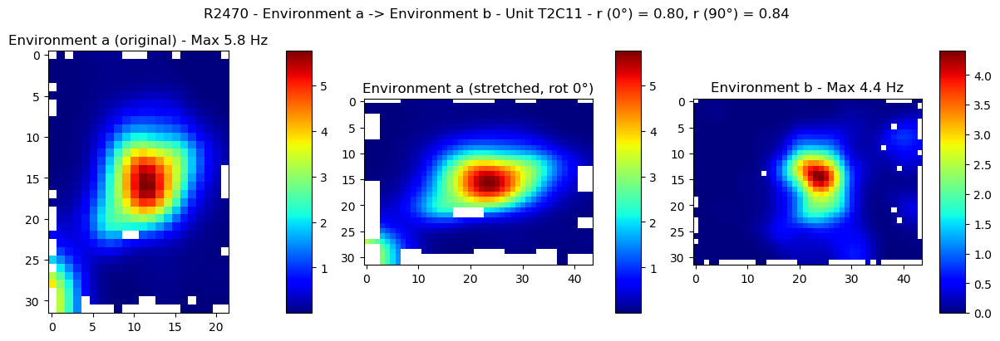

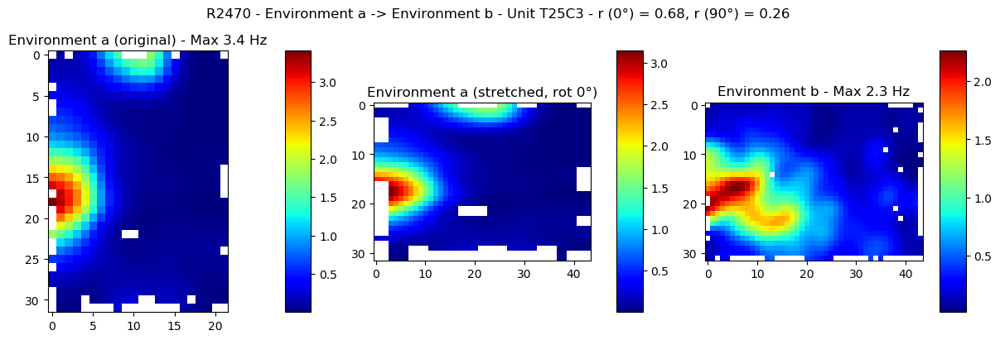

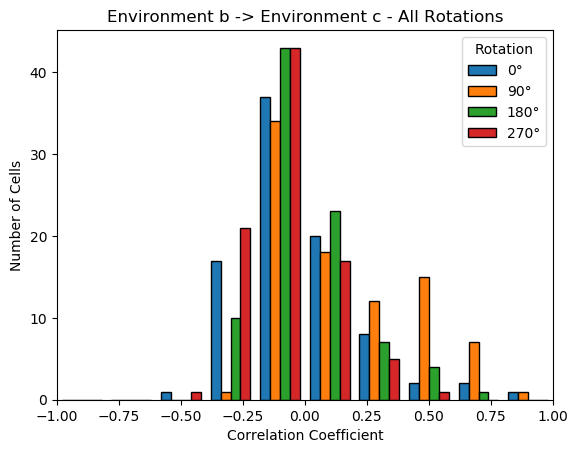

[Environment b -> Environment c] n units for statistical test: 88
[Environment b -> Environment c] n units before dropping NaNs: 88
[Environment b -> Environment c] Medians
  0°   : -0.044
  90°  : 0.091
 180°  : -0.043
 270°  : -0.110
[Environment b -> Environment c] Means
  0°   : -0.014
  90°  : 0.176
 180°  : 0.000
 270°  : -0.083


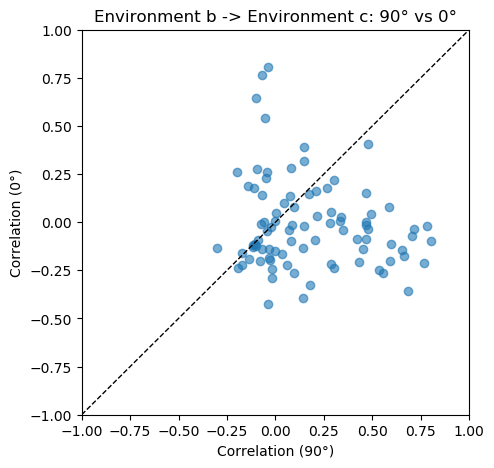

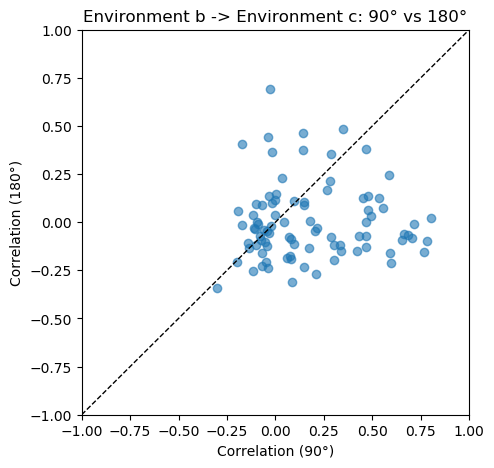

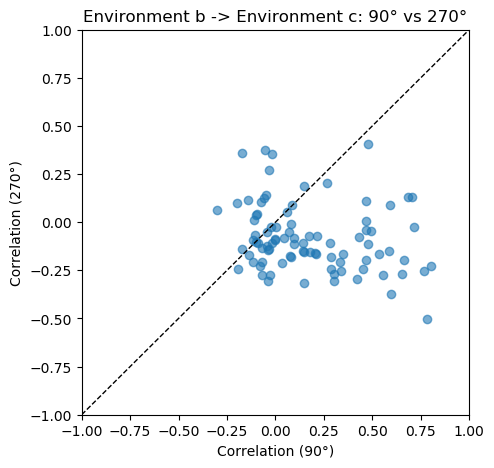

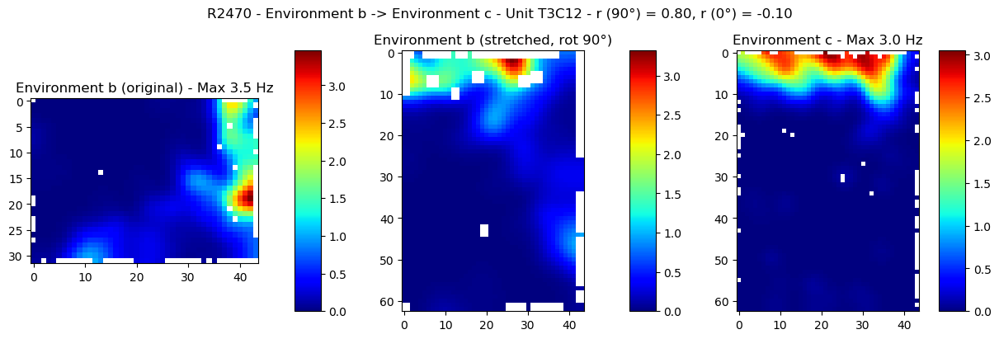

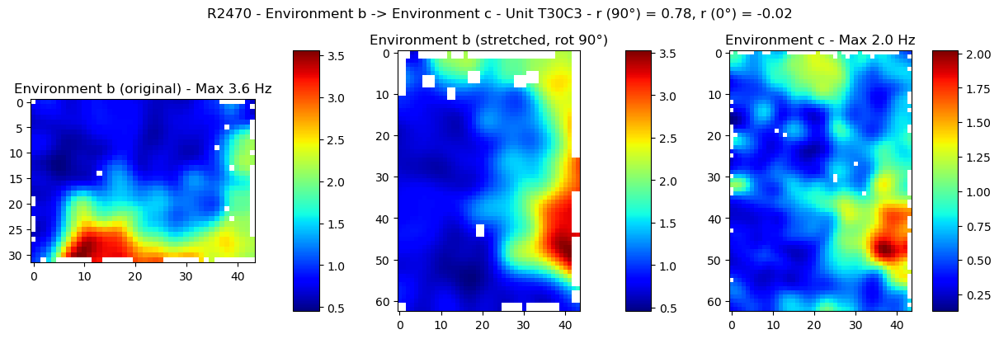

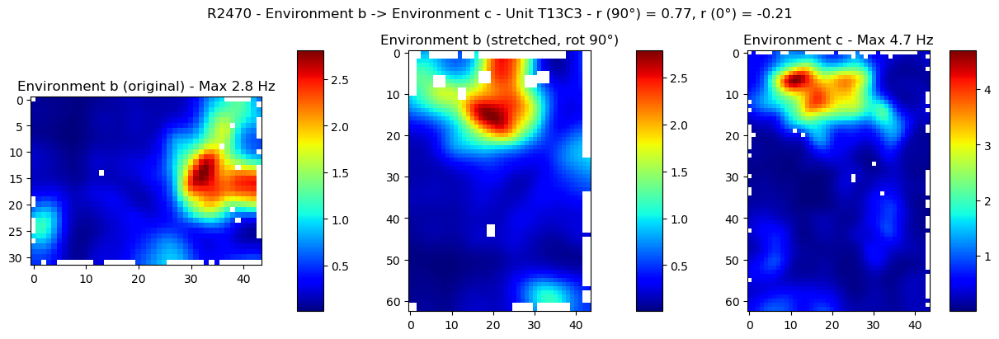

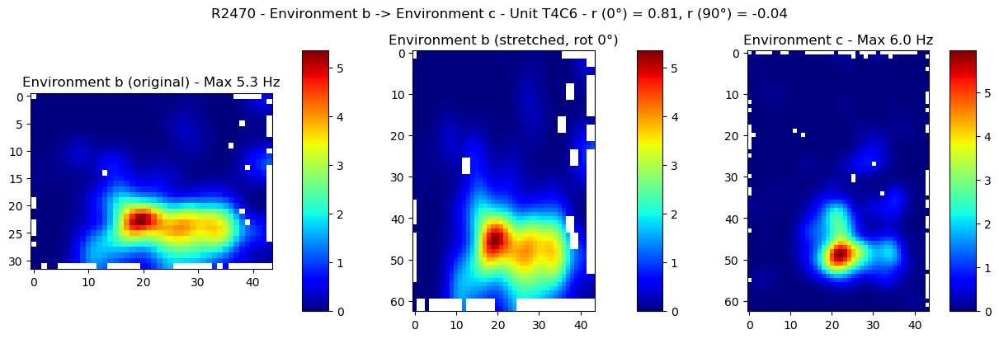

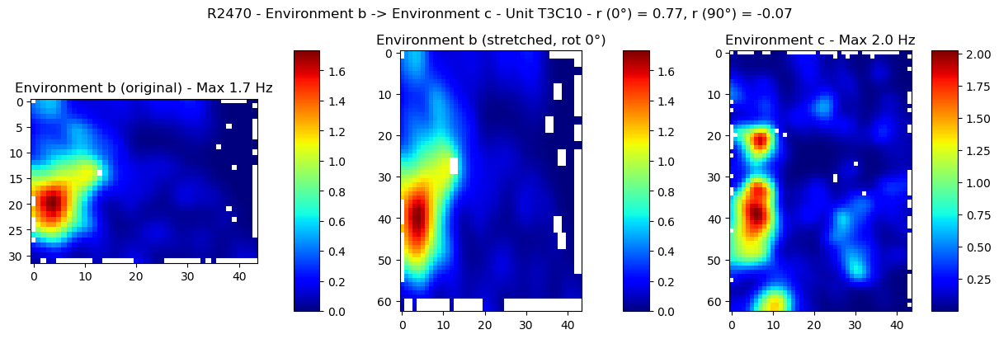

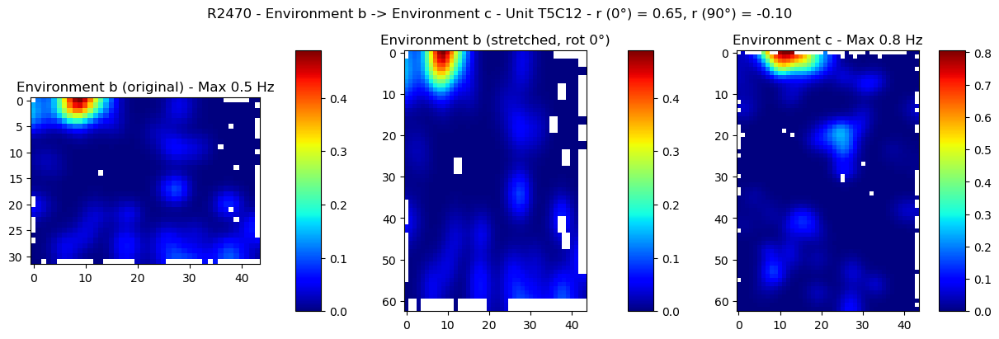

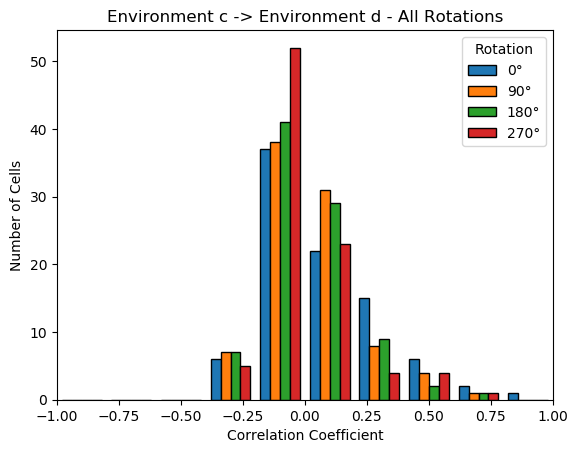

[Environment c -> Environment d] n units for statistical test: 89
[Environment c -> Environment d] n units before dropping NaNs: 89
[Environment c -> Environment d] Medians
  0°   : 0.030
  90°  : -0.003
 180°  : -0.014
 270°  : -0.032
[Environment c -> Environment d] Means
  0°   : 0.081
  90°  : 0.030
 180°  : 0.014
 270°  : 0.001


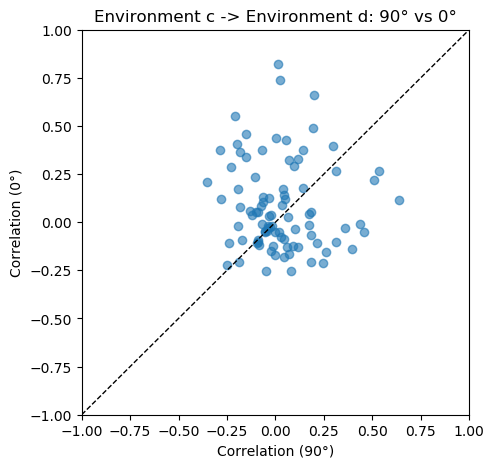

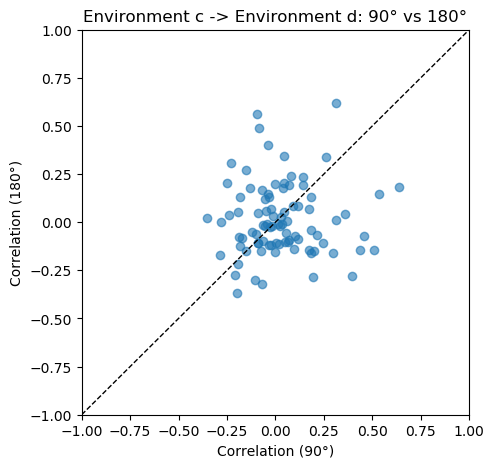

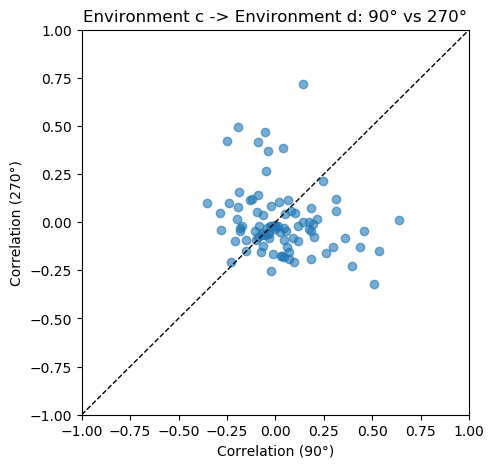

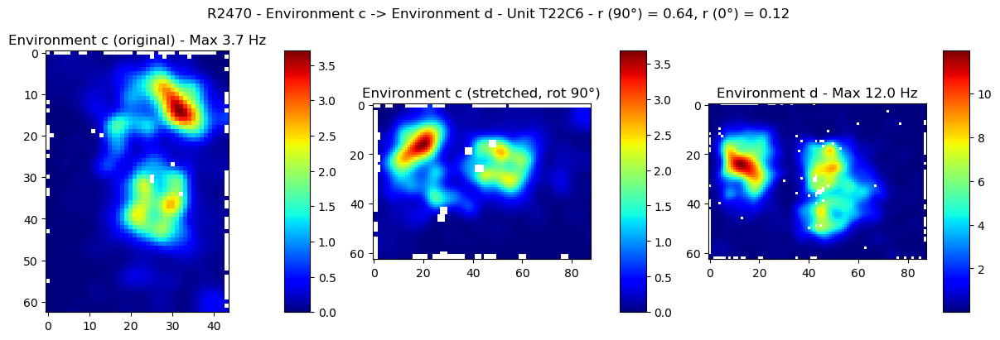

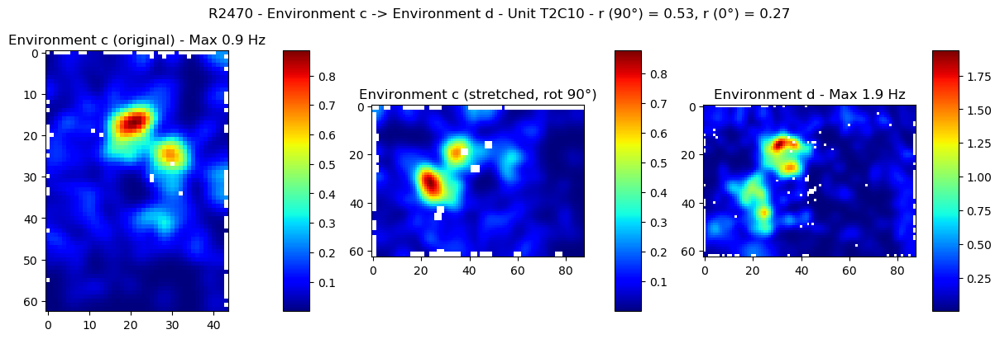

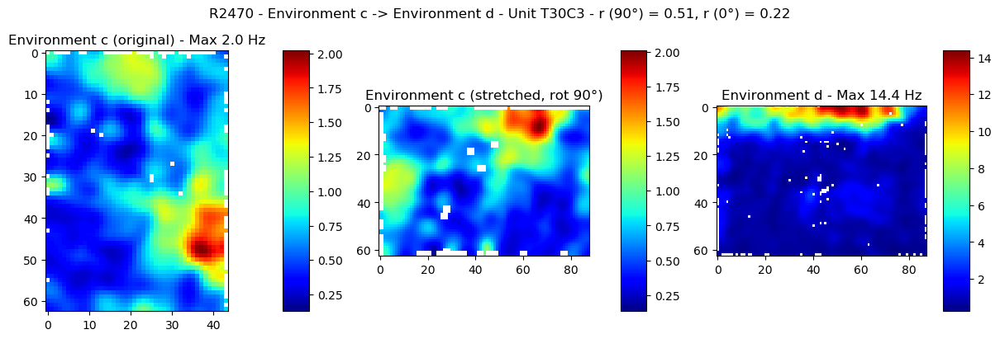

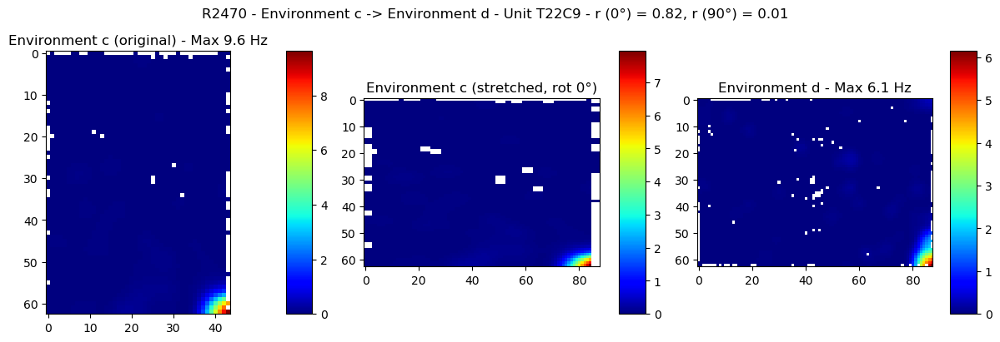

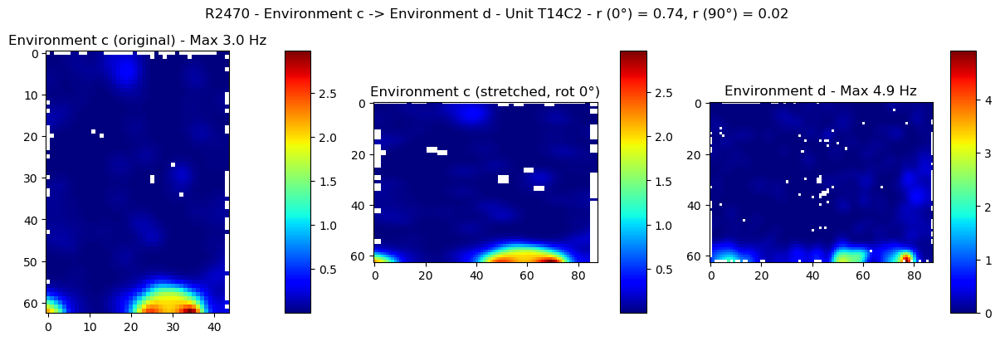

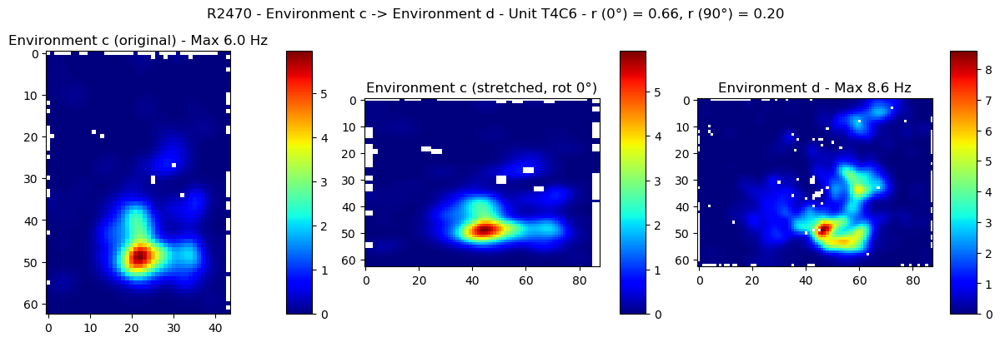

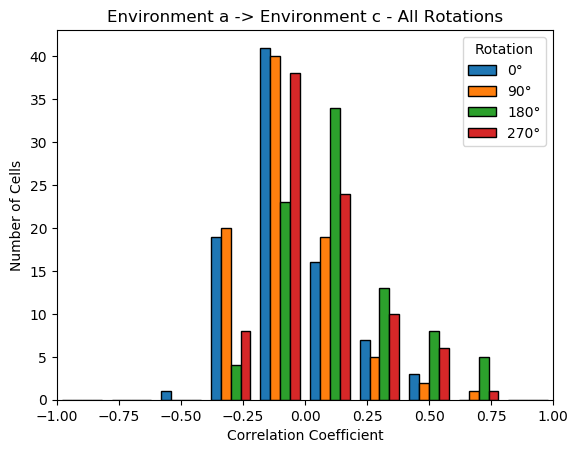

[Environment a -> Environment c] n units for statistical test: 87
[Environment a -> Environment c] n units before dropping NaNs: 87
[Environment a -> Environment c] Medians
  0°   : -0.084
  90°  : -0.076
 180°  : 0.084
 270°  : -0.001
[Environment a -> Environment c] Means
  0°   : -0.053
  90°  : -0.048
 180°  : 0.135
 270°  : 0.016


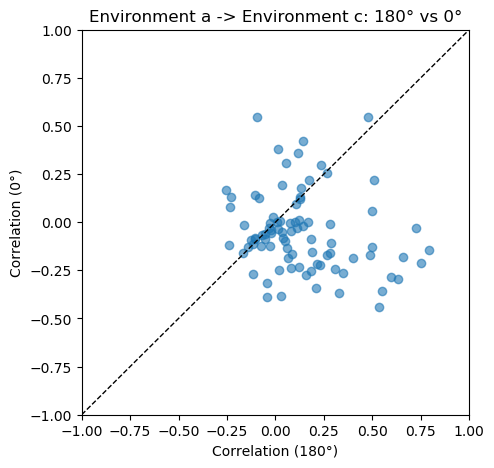

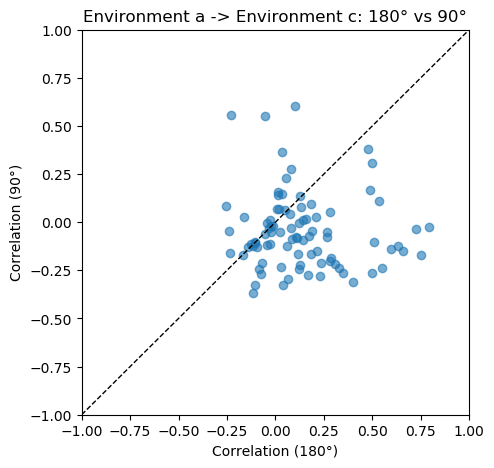

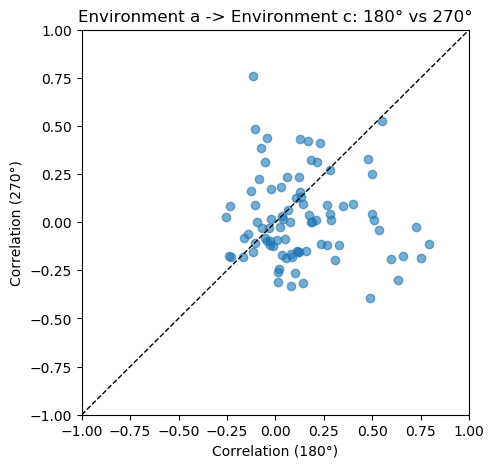

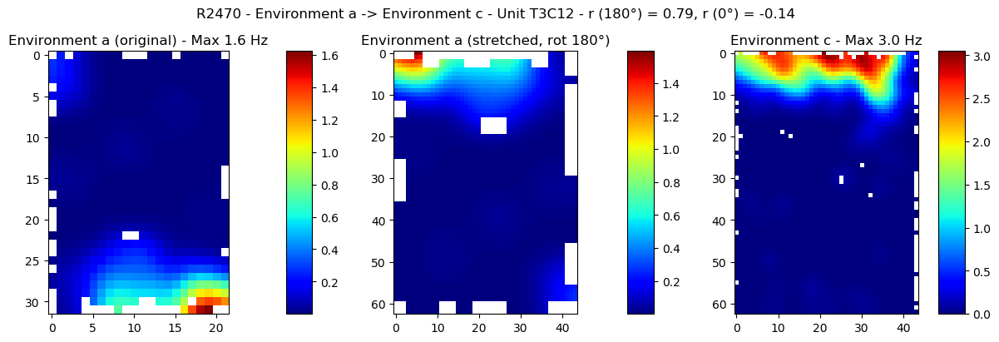

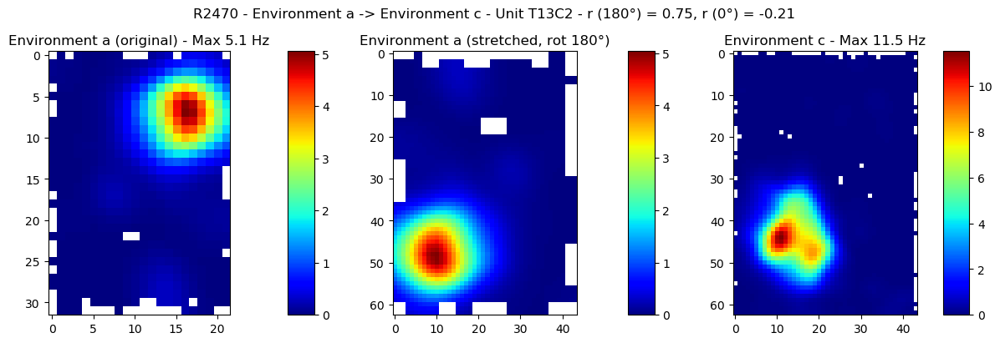

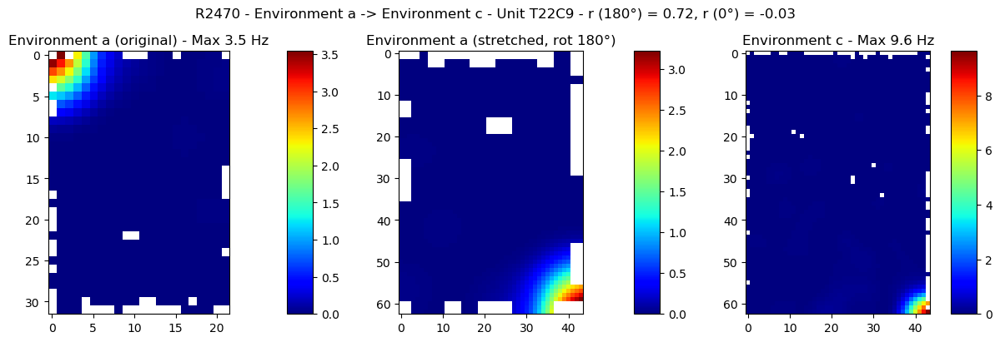

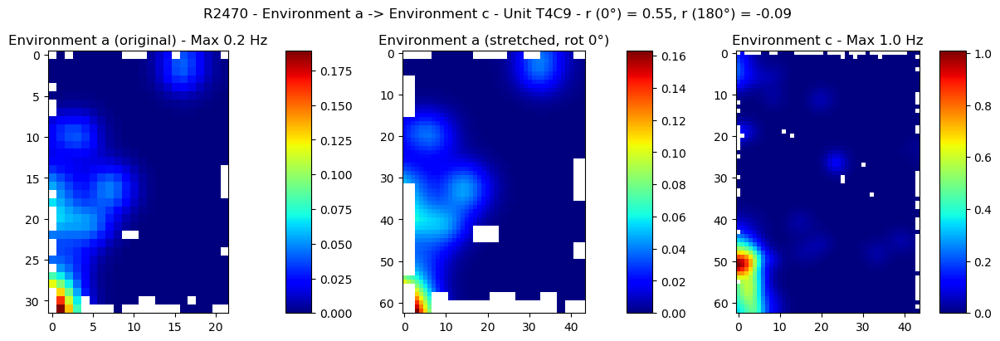

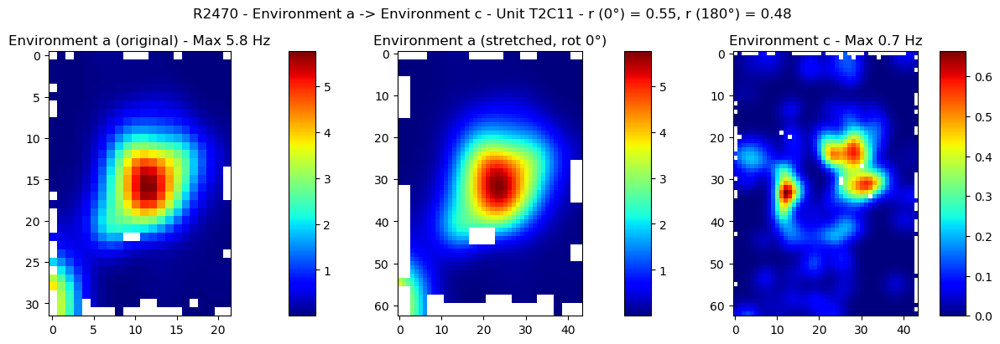

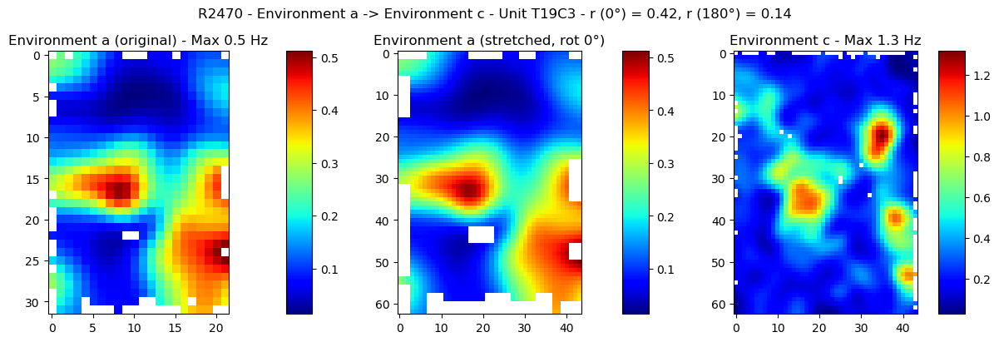

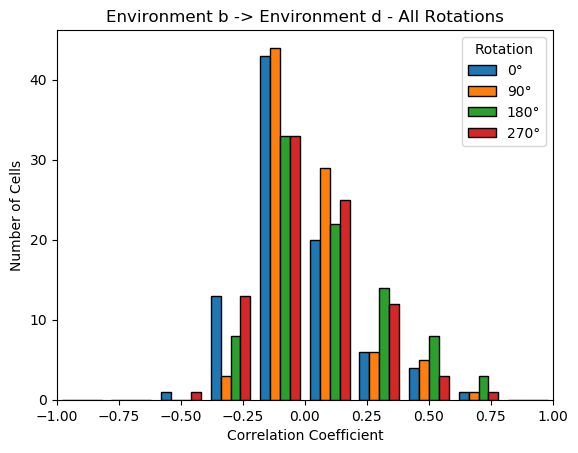

[Environment b -> Environment d] n units for statistical test: 88
[Environment b -> Environment d] n units before dropping NaNs: 88
[Environment b -> Environment d] Medians
  0°   : -0.055
  90°  : -0.021
 180°  : 0.032
 270°  : -0.009
[Environment b -> Environment d] Means
  0°   : -0.023
  90°  : 0.026
 180°  : 0.084
 270°  : 0.017


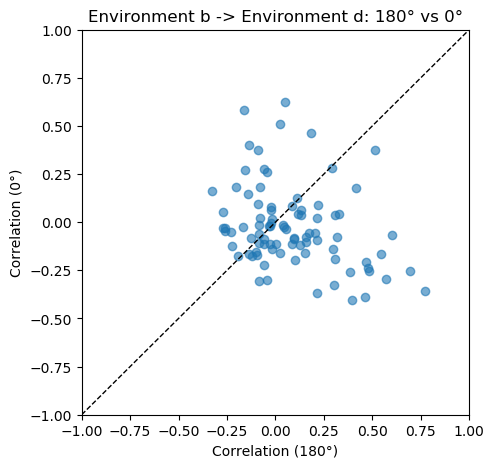

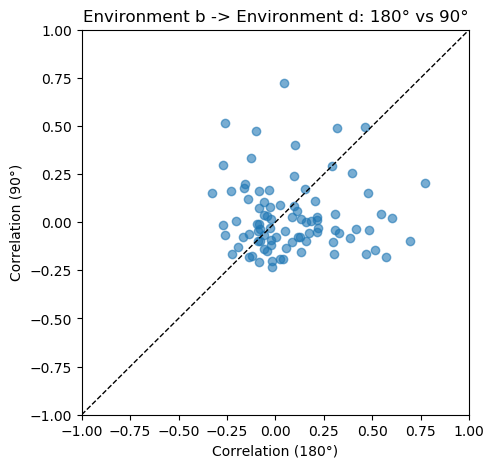

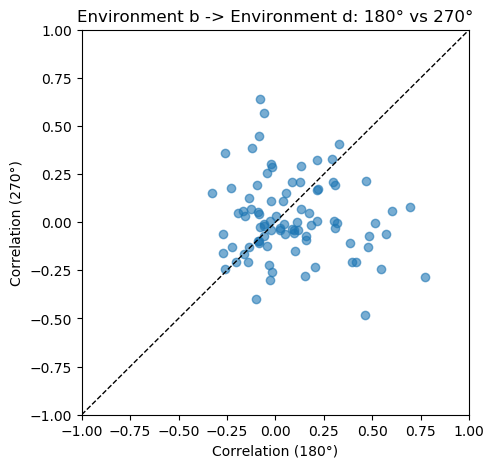

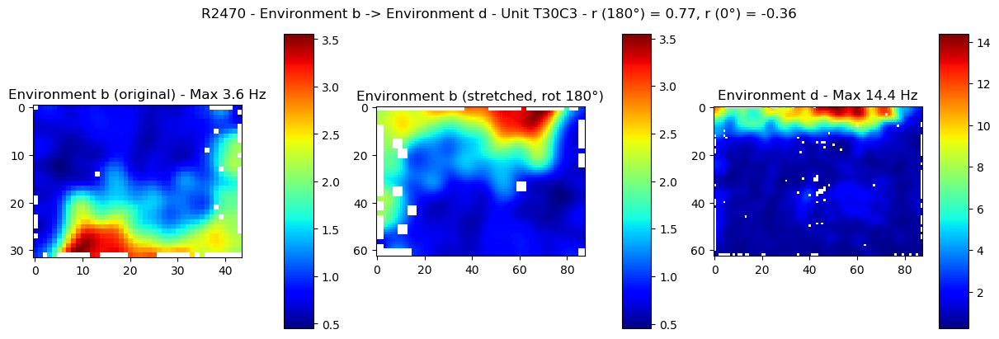

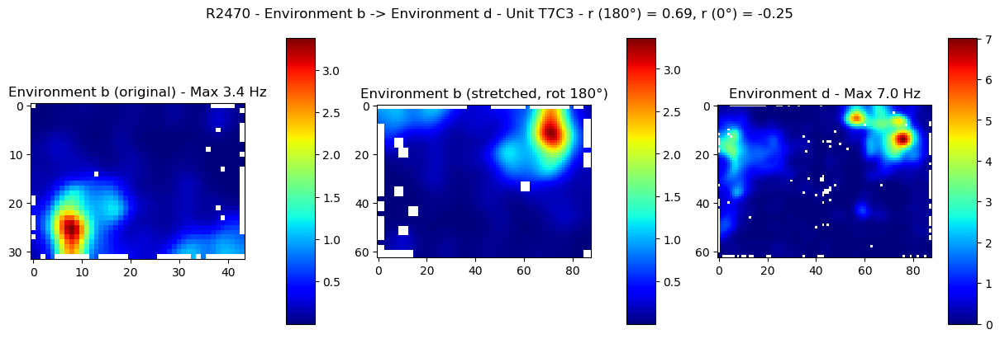

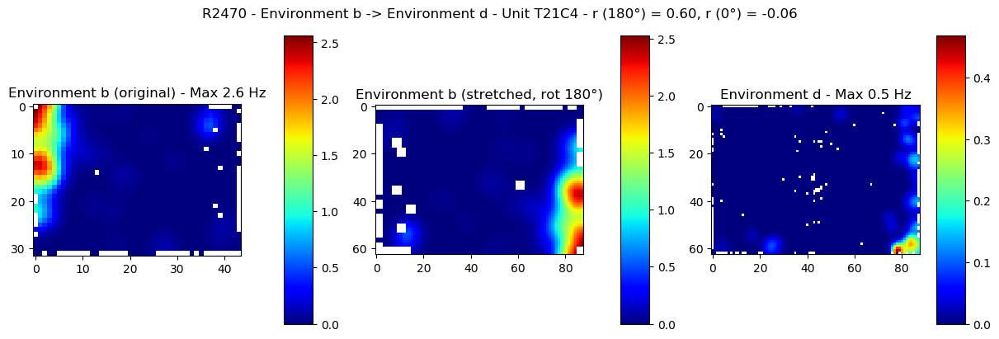

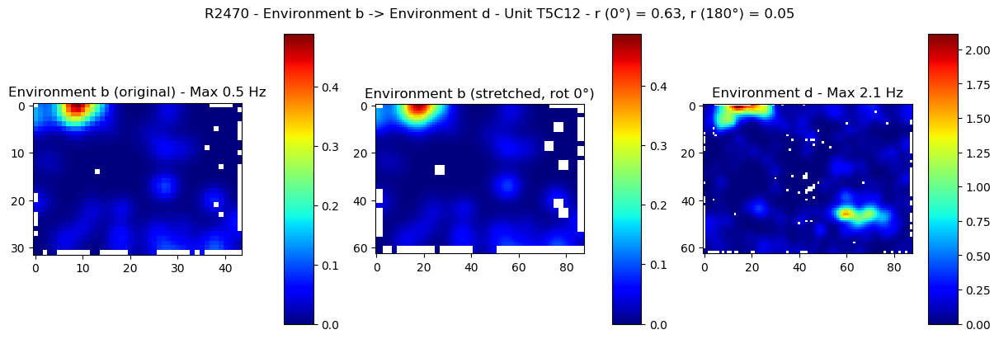

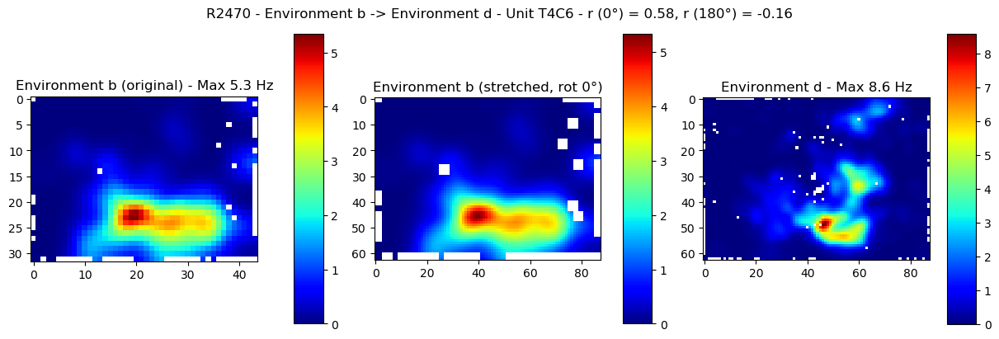

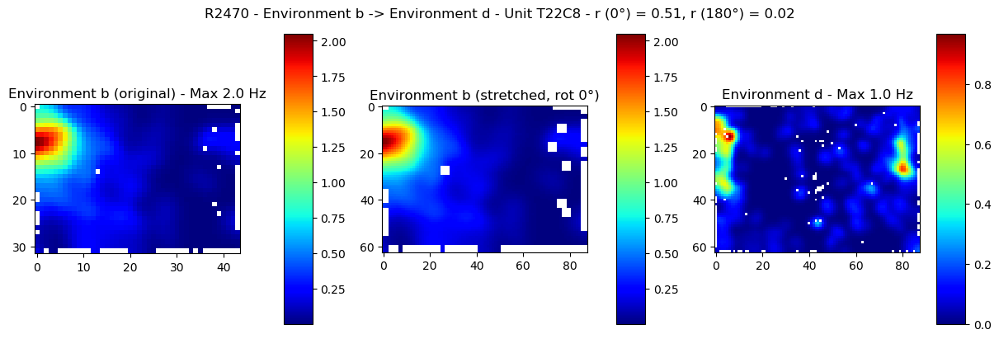

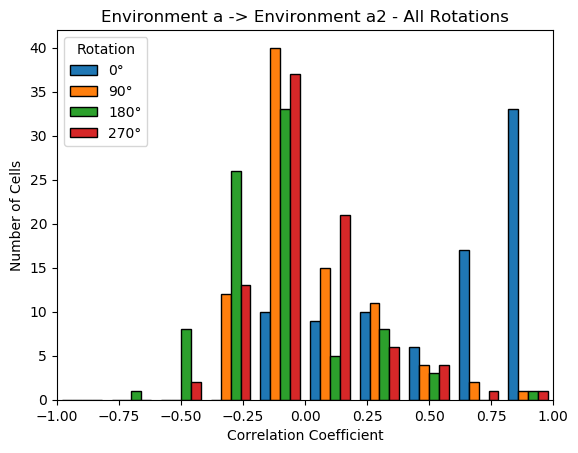

[Environment a -> Environment a2] n units for statistical test: 85
[Environment a -> Environment a2] n units before dropping NaNs: 85
[Environment a -> Environment a2] Medians
  0°   : 0.689
  90°  : -0.059
 180°  : -0.155
 270°  : -0.087
[Environment a -> Environment a2] Means
  0°   : 0.565
  90°  : 0.017
 180°  : -0.127
 270°  : -0.013


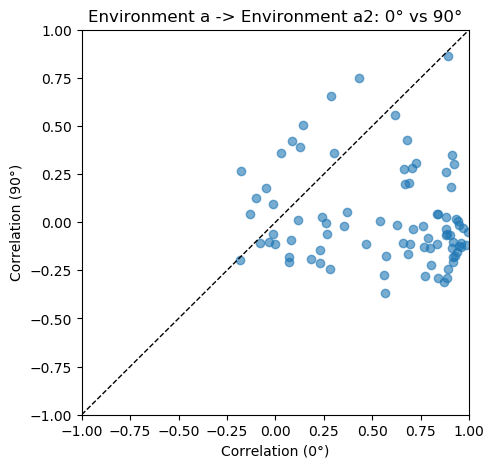

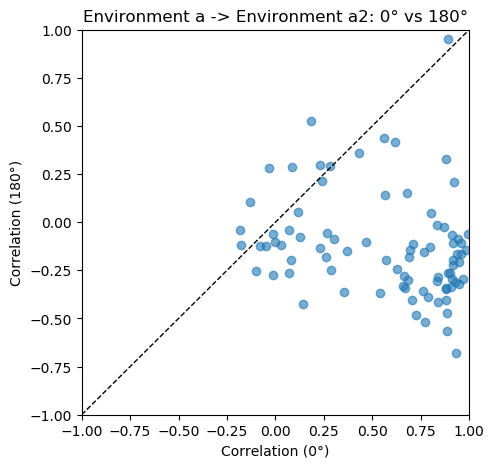

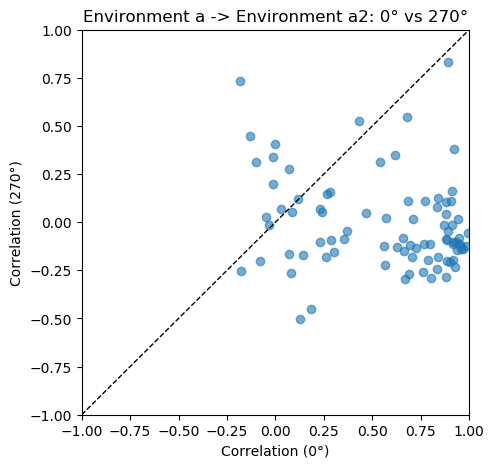

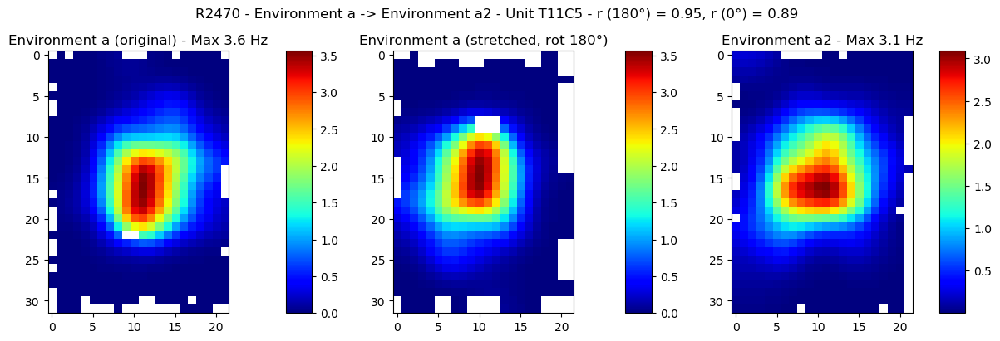

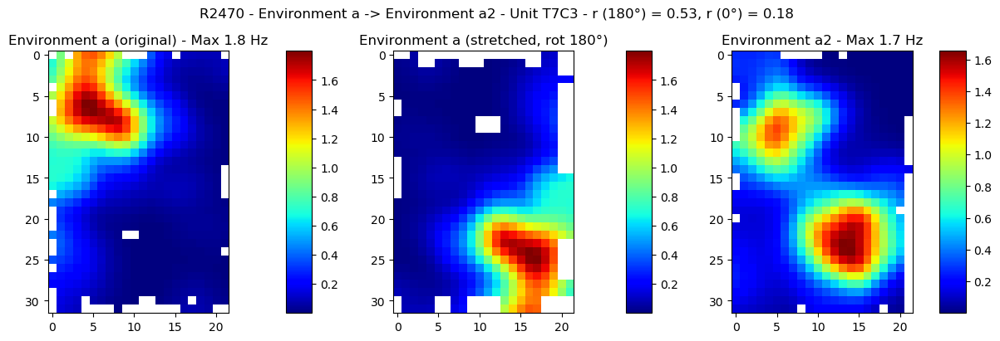

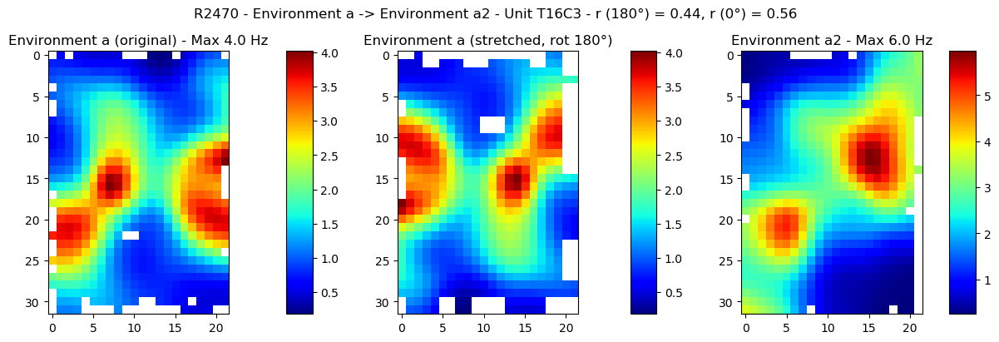

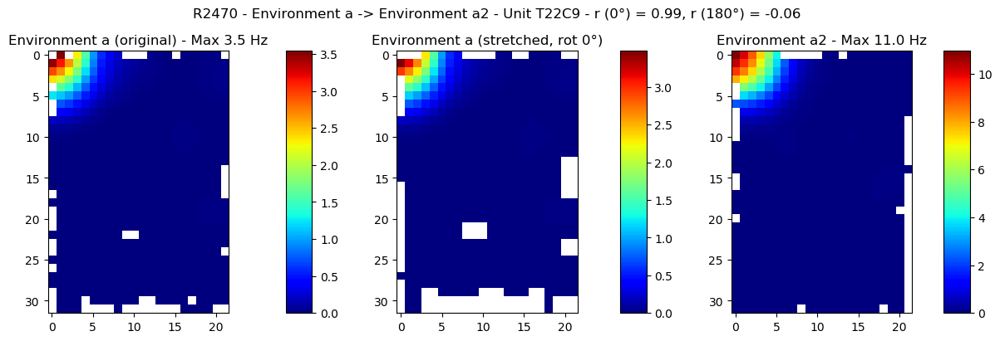

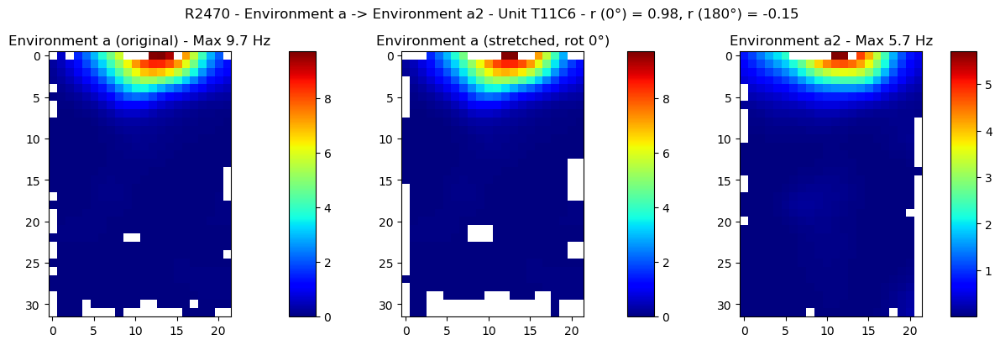

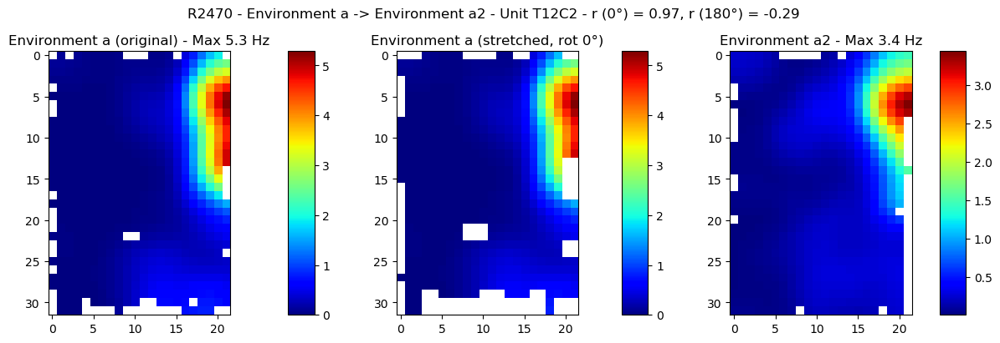

In [7]:

import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import statistics

import numpy as np


def get_ratemap_min_max(ratemap):
    arr = np.asarray(ratemap)
    return np.nanmin(arr), np.nanmax(arr)


def build_env_2_units(experiment_2):
    env_2_units = {}
    for unit in experiment_2.units:
        if unit.analysis.get("category") != "place_cell":
            continue

        unit_id_2 = (unit.tetrode_nr, unit.cluster_id)
        spatial = unit.analysis["spatial_ratemaps"]
        ratemap_2 = np.asarray(spatial["spike_rates_smoothed"], dtype=float)

        env_2_units[unit_id_2] = {
            "experiment": experiment_2,
            "unit": unit,
            "ratemap_2": ratemap_2,
            "ratemap_2_flat": ratemap_2.flatten(),
        }
    return env_2_units


def build_env_1_units(experiment_1, target_shape):
    env_1_units = {}

    def stretch(rotated):
        zf = (
            target_shape[0] / rotated.shape[0],
            target_shape[1] / rotated.shape[1],
        )
        return zoom(rotated, zf, order=1)

    for unit in experiment_1.units:
        if unit.analysis.get("category") != "place_cell":
            continue

        unit_id_1 = (unit.tetrode_nr, unit.cluster_id)
        spatial = unit.analysis["spatial_ratemaps"]
        ratemap_1 = np.asarray(spatial["spike_rates_smoothed"], dtype=float)

        rotated_0 = ratemap_1
        rotated_90 = np.flipud(ratemap_1.T)
        rotated_180 = np.flipud(rotated_90.T)
        rotated_270 = np.flipud(rotated_180.T)

        stretched_0 = stretch(rotated_0)
        stretched_90 = stretch(rotated_90)
        stretched_180 = stretch(rotated_180)
        stretched_270 = stretch(rotated_270)

        env_1_units[unit_id_1] = {
            "experiment": experiment_1,
            "unit": unit,
            "ratemap_1": ratemap_1,
            "rotated_0": rotated_0,
            "rotated_90": rotated_90,
            "rotated_180": rotated_180,
            "rotated_270": rotated_270,
            "stretched_0": stretched_0,
            "stretched_90": stretched_90,
            "stretched_180": stretched_180,
            "stretched_270": stretched_270,
            "flat_0": stretched_0.flatten(),
            "flat_90": stretched_90.flatten(),
            "flat_180": stretched_180.flatten(),
            "flat_270": stretched_270.flatten(),
        }
    return env_1_units


def per_unit_remapping_correlation_different_rotations(all_unit_ids, env_1_units, env_2_units, rotation=90, filter_out_cells_with_no_activity=True):
    results_units = {}
    results_histogram = []

    for unit_id in all_unit_ids:
        if unit_id not in env_1_units or unit_id not in env_2_units:
            continue

        ratemap_1_flat = env_1_units[unit_id][f"flat_{rotation}"]
        ratemap_2_flat = env_2_units[unit_id]["ratemap_2_flat"]

        valid = np.isfinite(ratemap_1_flat) & np.isfinite(ratemap_2_flat)

        if filter_out_cells_with_no_activity:
            _, max_val_1 = get_ratemap_min_max(ratemap_1_flat)
            _, max_val_2 = get_ratemap_min_max(ratemap_2_flat)
            passes = np.sum(valid) > 3 and max_val_1 > 0 and max_val_2 > 0
        else:
            passes = np.sum(valid) > 3

        if not passes:
            continue

        r = np.corrcoef(ratemap_1_flat[valid], ratemap_2_flat[valid])[0, 1]
        results_histogram.append(r)
        results_units[unit_id] = r

    return results_units, results_histogram


def Remapping_Histogramm(results_histogram, title=""):
    plt.hist(results_histogram, bins=10, edgecolor='k')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Number of Cells')
    plt.xlim(-1, 1)
    plt.title(title)
    plt.show()


def Remapping_Histogramm_Combined(histograms_by_rotation, title=""):
    rotations = [0, 90, 180, 270]
    colors = {0: "tab:blue", 90: "tab:orange", 180: "tab:green", 270: "tab:red"}

    data = []
    labels = []
    color_list = []
    for rot in rotations:
        data.append(histograms_by_rotation[rot])
        labels.append(f"{rot}°")
        color_list.append(colors[rot])

    plt.hist(data, bins=10, range=(-1, 1), color=color_list, label=labels, edgecolor='k')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Number of Cells')
    plt.xlim(-1, 1)
    plt.legend(title="Rotation")
    plt.title(title)
    plt.show()


def control_significance_of_rotation(pair_results, pair_label="", baseline_rotation=90, comparison_rotations=(0, 180, 270)):
    all_rotations = (0, 90, 180, 270)

    all_sets = []
    for rot in all_rotations:
        unit_ids = set(pair_results[rot]["units"].keys())
        all_sets.append(unit_ids)

    common_ids = all_sets[0]
    for s in all_sets[1:]:
        common_ids = common_ids.intersection(s)

    filtered_ids = []
    for uid in common_ids:
        has_nan = False
        for rot in all_rotations:
            value = pair_results[rot]["units"][uid]
            if np.isnan(value):
                has_nan = True
                break
        if not has_nan:
            filtered_ids.append(uid)

    print(f"[{pair_label}] n units for statistical test: {len(filtered_ids)}")
    print(f"[{pair_label}] n units before dropping NaNs: {len(common_ids)}")

    r_by_rot = {}
    for rot in all_rotations:
        values = []
        for uid in filtered_ids:
            values.append(pair_results[rot]["units"][uid])
        r_by_rot[rot] = np.array(values)

    r_0 = r_by_rot[0]
    r_90 = r_by_rot[90]
    r_180 = r_by_rot[180]
    r_270 = r_by_rot[270]

    print(
        f"[{pair_label}] Medians\n"
        f"  0°   : {np.median(r_0):.3f}\n"
        f"  90°  : {np.median(r_90):.3f}\n"
        f" 180°  : {np.median(r_180):.3f}\n"
        f" 270°  : {np.median(r_270):.3f}"
    )

    print(
        f"[{pair_label}] Means\n"
        f"  0°   : {np.mean(r_0):.3f}\n"
        f"  90°  : {np.mean(r_90):.3f}\n"
        f" 180°  : {np.mean(r_180):.3f}\n"
        f" 270°  : {np.mean(r_270):.3f}"
    )

    return r_by_rot, filtered_ids


def Remapping_BarPlot(results_units, title="", category_by_unit_id=None):
    sortable = []
    for uid, r in results_units.items():
        sort_value = np.inf if np.isnan(r) else r
        sortable.append((sort_value, uid, r))
    sortable.sort()

    unit_ids_sorted = []
    r_values_sorted = []
    for sort_value, uid, r in sortable:
        unit_ids_sorted.append(uid)
        r_values_sorted.append(r)

    labels = []
    for uid in unit_ids_sorted:
        label = f"T{uid[0]}C{uid[1]}"
        if category_by_unit_id is not None:
            label += f" ({category_by_unit_id.get(uid, 'unknown')})"
        labels.append(label)

    bar_colors = []
    for r in r_values_sorted:
        if r < 0:
            bar_colors.append("crimson")
        else:
            bar_colors.append("steelblue")

    plt.figure(figsize=(8, max(4, len(labels) * 0.2)))
    plt.barh(labels, r_values_sorted, color=bar_colors)
    plt.xlabel("Correlation Coefficient (r)")
    plt.ylabel("Unit")
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)
    plt.title(f"Per-unit remapping correlation - {title}")
    plt.tight_layout()
    plt.show()


def plot_rotation_scatter(pair_results, rotation_x=0, rotation_y=90, pair_label=""):
    unit_ids_x = set(pair_results[rotation_x]["units"].keys())
    unit_ids_y = set(pair_results[rotation_y]["units"].keys())

    common_ids = unit_ids_x.intersection(unit_ids_y)

    filtered_ids = []
    for uid in common_ids:
        value_x = pair_results[rotation_x]["units"][uid]
        value_y = pair_results[rotation_y]["units"][uid]
        if not np.isnan(value_x) and not np.isnan(value_y):
            filtered_ids.append(uid)

    corr_x = []
    corr_y = []
    for uid in filtered_ids:
        corr_x.append(pair_results[rotation_x]["units"][uid])
        corr_y.append(pair_results[rotation_y]["units"][uid])

    corr_x = np.array(corr_x)
    corr_y = np.array(corr_y)

    plt.figure(figsize=(5, 5))
    plt.scatter(corr_x, corr_y, alpha=0.6)
    plt.plot([-1, 1], [-1, 1], 'k--', lw=1)
    plt.xlabel(f'Correlation ({rotation_x}°)')
    plt.ylabel(f'Correlation ({rotation_y}°)')
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.title(f"{pair_label}: {rotation_x}° vs {rotation_y}°")
    plt.show()


def plot_unit_ratemaps(env_1_units, env_2_units, results_units, rotation, pair_label="", max_units_to_plot=5, unit_ids=None, other_rotation=None, other_rotation_results=None):
    stretched_key = f"stretched_{rotation}"

    if " -> " in pair_label:
        exp_1_label, exp_2_label = pair_label.split(" -> ")
    else:
        exp_1_label, exp_2_label = "Environment 1", "Environment 2"

    i = 0
    rat_id = cache_file.name.replace("_experiments.npy", "")

    if unit_ids is None:
        sortable = []
        for uid, r in results_units.items():
            if not np.isnan(r):
                sortable.append((r, uid))
        sortable.sort(reverse=True)

        unit_ids = []
        for r, uid in sortable:
            unit_ids.append(uid)

    for unit_id in unit_ids:
        if i >= max_units_to_plot:
            break

        r = results_units[unit_id]

        ratemap_1 = env_1_units[unit_id]["ratemap_1"]
        stretched = env_1_units[unit_id][stretched_key]
        ratemap_2 = env_2_units[unit_id]["ratemap_2"]

        _, ratemap_max_1 = get_ratemap_min_max(ratemap_1)
        _, ratemap_max_2 = get_ratemap_min_max(ratemap_2)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

        category = env_1_units[unit_id]["unit"].analysis.get("category", "unknown")

        title = f"{rat_id} - {pair_label} - Unit T{unit_id[0]}C{unit_id[1]} - r ({rotation}°) = {r:.2f}"
        if other_rotation is not None and other_rotation_results is not None:
            other_r = other_rotation_results.get(unit_id, float("nan"))
            title += f", r ({other_rotation}°) = {other_r:.2f}"
        fig.suptitle(title)

        im0 = axes[0].imshow(ratemap_1, cmap="jet")
        axes[0].set_title(f"{exp_1_label} (original) - Max {ratemap_max_1:.1f} Hz")
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, aspect=30)

        im1 = axes[1].imshow(stretched, cmap="jet")
        axes[1].set_title(f"{exp_1_label} (stretched, rot {rotation}°)")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, aspect=30)

        im2 = axes[2].imshow(ratemap_2, cmap="jet")
        axes[2].set_title(f"{exp_2_label} - Max {ratemap_max_2:.1f} Hz")
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, aspect=30)

        plt.show()

        i += 1

    return unit_ids[:max_units_to_plot]


def run_remapping_analysis_for_pair(experiment_1, experiment_2, pair_label="", make_detailed_plots=False, baseline_rotation=90, comparison_rotations=(0, 180, 270), skip_one=True):
    env_2_units = build_env_2_units(experiment_2)

    for unit in env_2_units.values():
        first_unit = unit
        break
    target_shape = first_unit["ratemap_2"].shape
    env_1_units = build_env_1_units(experiment_1, target_shape)

    category_by_unit_id = {}
    for unit_id, unit_data in env_1_units.items():
        category_by_unit_id[unit_id] = unit_data["unit"].analysis.get("category", "unknown")

    all_unit_ids = set(env_1_units.keys()) | set(env_2_units.keys())
    pair_results = {}
    histograms_by_rotation = {}

    for rotation in (0, 90, 180, 270):
        results_units, results_hist = per_unit_remapping_correlation_different_rotations(all_unit_ids, env_1_units, env_2_units, rotation=rotation)
        histograms_by_rotation[rotation] = results_hist

        mean_corr = statistics.mean(results_hist)
        median_corr = statistics.median(results_hist)

        pair_results[rotation] = {
            "units": results_units,
            "histogram": results_hist,
            "mean": mean_corr,
            "median": median_corr,
        }

        if make_detailed_plots:
            Remapping_BarPlot(results_units, title=f"{pair_label} - Rotation {rotation}°", category_by_unit_id=category_by_unit_id)

    Remapping_Histogramm_Combined(histograms_by_rotation, title=f"{pair_label} - All Rotations")

    control_significance_of_rotation(pair_results, pair_label=pair_label, baseline_rotation=baseline_rotation, comparison_rotations=comparison_rotations)

    for rot in comparison_rotations:
        plot_rotation_scatter(pair_results, rotation_x=baseline_rotation, rotation_y=rot, pair_label=pair_label)

    if not skip_one:
        plot_unit_ratemaps(
            env_1_units, env_2_units, pair_results[90]["units"], rotation=90,
            pair_label=pair_label, max_units_to_plot=3,
            other_rotation=0, other_rotation_results=pair_results[0]["units"],
        )
        plot_unit_ratemaps(
            env_1_units, env_2_units, pair_results[0]["units"], rotation=0,
            pair_label=pair_label, max_units_to_plot=3,
            other_rotation=90, other_rotation_results=pair_results[90]["units"],
        )
    else:
        plot_unit_ratemaps(
            env_1_units, env_2_units, pair_results[180]["units"], rotation=180,
            pair_label=pair_label, max_units_to_plot=3,
            other_rotation=0, other_rotation_results=pair_results[0]["units"],
        )
        plot_unit_ratemaps(
            env_1_units, env_2_units, pair_results[0]["units"], rotation=0,
            pair_label=pair_label, max_units_to_plot=3,
            other_rotation=180, other_rotation_results=pair_results[180]["units"],
        )
    return pair_results


def run_remapping_analysis_skip_one(experiments):
    skip_pairs_results = {}

    for i in range(2):
        experiment_1 = experiments[i]
        experiment_2 = experiments[i + 2]
        if i == 0:
            pair_label = f"Environment a -> Environment c"
        elif i == 1:
            pair_label = f"Environment b -> Environment d"
        skip_pairs_results[(i, i + 2)] = run_remapping_analysis_for_pair(
            experiment_1, experiment_2, pair_label=pair_label, baseline_rotation=180, comparison_rotations=(0, 90, 270), skip_one=True)

    return skip_pairs_results


all_pairs_results = {}

for i in range(3):
    experiment_1 = experiments[i]
    experiment_2 = experiments[i + 1]
    if i == 0:
        pair_label = f"Environment a -> Environment b"
    elif i == 1:
        pair_label = f"Environment b -> Environment c"
    elif i == 2:
        pair_label = f"Environment c -> Environment d"
    all_pairs_results[(i, i + 1)] = run_remapping_analysis_for_pair(
        experiment_1, experiment_2, pair_label=pair_label, baseline_rotation=90, comparison_rotations=(0, 180, 270), skip_one=False)


skip_pairs_results = run_remapping_analysis_skip_one(experiments)


def find_experiment_by_id(experiments, experiment_id):
    for experiment in experiments:
        if experiment.info["experiment_id"] == experiment_id:
            return experiment
    raise KeyError(f"No experiment with id {experiment_id!r} found")


experiment_a = find_experiment_by_id(experiments, "exp_scales_a")
experiment_a2 = find_experiment_by_id(experiments, "exp_scales_a2")

a_to_a2_results = run_remapping_analysis_for_pair(
    experiment_a, experiment_a2, pair_label="Environment a -> Environment a2",
    baseline_rotation=0, comparison_rotations=(90, 180, 270), skip_one=True,
)

**Identify the Subpopulation of Rotationallly remapping Cells**

In [8]:

def identify_blob_units(all_pairs_results, skip_pairs_results, baseline_rotation=90,comparison_rotation=(0, 180, 270), z_threshold=1.0, skip_one=True, threshold_method="z-score", percentile=10.0):
    all_blob_ids = {}
    all_differences = {}

    if skip_one:
        pair_keys = []
        for i in range(2):
            pair_keys.append((i, i + 2))
        results_source = skip_pairs_results
    else:
        pair_keys = []
        for i in range(3):
            pair_keys.append((i, i + 1))
        results_source = all_pairs_results

    for pair_key in pair_keys:
        for rot in comparison_rotation:
            baseline_units = results_source[pair_key][baseline_rotation]["units"]
            compare_units = results_source[pair_key][rot]["units"]

            common_ids = set(baseline_units.keys()) & set(compare_units.keys())
            differences = {}
            for uid in common_ids:
                b = baseline_units[uid]
                compare_val = compare_units[uid]
                if not np.isnan(b) and not np.isnan(compare_val):
                    differences[uid] = b - compare_val

            diff_values = np.array(list(differences.values()))
            if threshold_method == "z-score":
                cutoff = diff_values.mean() + z_threshold * diff_values.std()
            elif threshold_method == "percentile":
                cutoff = np.percentile(diff_values, 100.0 - percentile)
            else:
                raise ValueError(f"Unknown threshold_method: {threshold_method}")
            blob_ids = set()
            for uid in differences:
                d = differences[uid]
                if d >= cutoff:
                    blob_ids.add(uid)

            all_blob_ids[(pair_key, rot)] = blob_ids
            all_differences[(pair_key, rot)] = differences

    return all_blob_ids, all_differences


all_blob_ids_all_pairs, all_differences_all_pairs = identify_blob_units(all_pairs_results, skip_pairs_results, baseline_rotation=90,comparison_rotation=(0, 180, 270), z_threshold=0.9, skip_one=False, threshold_method="z-score")
all_blob_ids_skip_one, all_differences_skip_one = identify_blob_units(all_pairs_results, skip_pairs_results, baseline_rotation=90,comparison_rotation=(0, 180, 270), z_threshold=0.9, skip_one=True, threshold_method="z-score")

a_b = all_blob_ids_all_pairs[(0, 1), 0]
b_c = all_blob_ids_all_pairs[(1, 2), 0]
c_d = all_blob_ids_all_pairs[(2, 3), 0]

a_c = all_blob_ids_skip_one[(0, 2), 0]
b_d = all_blob_ids_skip_one[(1,3), 0]

PERCENTILE_FOR_BLOB_ANALYSIS = 10.0
all_blob_ids_all_pairs_percentile, all_differences_all_pairs_percentile = identify_blob_units(all_pairs_results, skip_pairs_results, baseline_rotation=90,comparison_rotation=(0, 180, 270), skip_one=False, threshold_method="percentile", percentile=PERCENTILE_FOR_BLOB_ANALYSIS)
all_blob_ids_skip_one_percentile, all_differences_skip_one_percentile = identify_blob_units(all_pairs_results, skip_pairs_results, baseline_rotation=90,comparison_rotation=(0, 180, 270), skip_one=True, threshold_method="percentile", percentile=PERCENTILE_FOR_BLOB_ANALYSIS)

a_b_percentile = all_blob_ids_all_pairs_percentile[(0, 1), 0]
b_c_percentile = all_blob_ids_all_pairs_percentile[(1, 2), 0]
c_d_percentile = all_blob_ids_all_pairs_percentile[(2, 3), 0]

a_c_percentile = all_blob_ids_skip_one_percentile[(0, 2), 0]
b_d_percentile = all_blob_ids_skip_one_percentile[(1,3), 0]

print(all_blob_ids_all_pairs[(0, 1), 0])
print(all_blob_ids_all_pairs[(1, 2), 0])
print(all_blob_ids_all_pairs[(2, 3), 0])

print(all_blob_ids_skip_one[(0, 2), 0])
print(all_blob_ids_skip_one[(1,3), 0])

blob_sets_by_label = {
    "a_b": a_b,
    "b_c": b_c,
    "c_d": c_d,
    "a_c": a_c,
    "b_d": b_d,
}
pair_labels = list(blob_sets_by_label.keys())

blob_candidates_by_label = {
    "a_b": set(all_differences_all_pairs[(0, 1), 0].keys()),
    "b_c": set(all_differences_all_pairs[(1, 2), 0].keys()),
    "c_d": set(all_differences_all_pairs[(2, 3), 0].keys()),
    "a_c": set(all_differences_skip_one[(0, 2), 0].keys()),
    "b_d": set(all_differences_skip_one[(1, 3), 0].keys()),
}



{(7, 3), (12, 2), (3, 12), (11, 4), (18, 3), (13, 3), (30, 3), (13, 4), (19, 4), (18, 4), (22, 9), (21, 4), (2, 3), (22, 8), (0, 8), (5, 2), (16, 7)}
{(22, 3), (1, 3), (3, 12), (5, 11), (13, 3), (30, 3), (13, 4), (1, 4), (22, 5), (22, 9), (0, 5), (22, 8), (2, 5), (16, 7), (7, 2)}
{(22, 3), (15, 2), (30, 3), (11, 2), (5, 7), (21, 2), (18, 4), (22, 5), (2, 10), (15, 6), (22, 7), (0, 5), (22, 8), (22, 6), (4, 3), (0, 8), (7, 2)}
{(22, 3), (1, 3), (2, 9), (5, 11), (4, 5), (16, 4), (18, 5), (30, 3), (11, 3), (26, 9), (22, 8), (5, 8)}
{(1, 2), (3, 12), (15, 5), (25, 4), (5, 11), (11, 5), (30, 3), (16, 3), (5, 7), (22, 9), (25, 2), (2, 5), (25, 3), (5, 2)}
